# tensor_core_engine_v5.1 -- CUDA Fortran vs Rust (cuda-oxide), cell by cell

This is `benchmark_v5_1_RTX4060.ipynb` with every Fortran benchmark cell followed by the **same cell run against the Rust engine** (`rust_matrix_ops.RustMatrixOps`, backed by `librust_matlib.so`). The Rust cells are the Fortran cells with `TensorMatrixOps` swapped for `RustMatrixOps` and `[Rust]` added to titles -- nothing else changes, so each pair is a like-for-like comparison on this GPU. Result variables get a `_rust` suffix; a summary at the end puts the two engines side by side per operation.

Both libraries are loaded into this same kernel process. Cell 0 preloads the system cuBLAS (the py314 env bundles an older `libcublasLt` that CuPy would otherwise load first).

Tier notes: both engines use cuBLAS/cuBLASLt for the GEMMs at the same math modes (TF32 tensor cores, exact FP32, FP64), so they should land within run-to-run noise of each other; the Rust wrapper skips the Fortran wrapper's `asfortranarray` copies and per-stage device syncs, which shows up at small sizes.


In [1]:
# nvfortran's device-memory pool keeps freed Fortran workspace (wp_*) resident, so
# cuda_matlib's py_workspace_cleanup() frees nothing and the pool leaks across cells
# (~940 MB at the (8, 2048^3) shapes). NV_ACC_MEM_MANAGE=0 disables that pool; it must
# be set before cuda_matlib.so is loaded. Measured 2026-09-18: cleanup frees 0 MB -> 224 MB.
import os
os.environ.setdefault("NV_ACC_MEM_MANAGE", "0")

# Load the system CUDA 13.4 cuBLAS/cuBLASLt BEFORE cupy imports its own older
# bundled libcublasLt.so.13 (py314 env, v13.1.0.3). Otherwise cuda_matlib.so
# fails with "undefined symbol: cublasLtZZZMatmulAlgoGetHeuristicForStream".
# Same effect as run_with_system_cublas.sh / the "py314 (system cuBLAS)"
# kernel, but works in any kernel. See tensor_core_engine_rust/RESULTS.md.
import sys, os
sys.path.insert(0, os.getcwd())  # engine dir holds cublas_preload.py
from cublas_preload import preload_system_cublas
preload_system_cublas()

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from typing import Callable, List, Dict, Tuple, Any, Union
import gc

gc.collect()

def time_operation(operation: Callable, *args, repeat: int = 3) -> List[float]:
    """Time a GPU operation with proper synchronization.
    
    Args:
        operation: Function to time
        args: Arguments to pass to the operation
        repeat: Number of times to repeat timing
        
    Returns:
        List of elapsed times in seconds
    """
    times = []
    for _ in range(repeat):
        cp.cuda.runtime.deviceSynchronize()
        start = time.perf_counter()
        result = operation(*args)
        cp.cuda.Stream.null.synchronize()
        elapsed = time.perf_counter() - start
        times.append(elapsed)
    
    return result, times

def warmup_gpu(size: int = 1024, iterations: int = 5):
    """Warm up GPU clocks by running matrix multiplications.
    
    The A1000 (and most mobile GPUs) start at a lower boost clock and ramp up
    under sustained load. Without warmup, the first benchmark cell runs cold
    and appears ~30-40% slower than subsequent cells.
    
    Args:
        size: Matrix dimension for warmup matmuls
        iterations: Number of warmup matmuls to run
    """
    a = cp.random.random((size, size), dtype=cp.float64)
    b = cp.random.random((size, size), dtype=cp.float64)
    for _ in range(iterations):
        c = cp.matmul(a, b)
        cp.cuda.Stream.null.synchronize()
    del a, b, c
    cp.get_default_memory_pool().free_all_blocks()

def calculate_metrics(tensor_result, reference_result, tensor_times, reference_times, flops):
    """Calculate performance and accuracy metrics.
    
    Args:
        tensor_result: Result from tensor core implementation
        reference_result: Result from reference implementation
        tensor_times: List of timing results for tensor implementation
        reference_times: List of timing results for reference implementation
        flops: Number of floating-point operations
        
    Returns:
        Dictionary of metrics
    """
    # Performance metrics
    tensor_min_time = min(tensor_times)
    reference_min_time = min(reference_times)
    
    tensor_gflops = flops / (tensor_min_time * 1e9)
    reference_gflops = flops / (reference_min_time * 1e9)
    speedup = reference_min_time / tensor_min_time
    
    # Accuracy metrics
    max_diff = float(cp.max(cp.abs(tensor_result - reference_result)))
    mean_diff = float(cp.mean(cp.abs(tensor_result - reference_result)))
    
    # Sample outputs for verification
    if isinstance(tensor_result, cp.ndarray):
        tensor_sample = cp.asnumpy(tensor_result.reshape(-1)[:5])
        reference_sample = cp.asnumpy(reference_result.reshape(-1)[:5])
    else:
        tensor_sample = tensor_result[:5] if hasattr(tensor_result, '__getitem__') else tensor_result
        reference_sample = reference_result[:5] if hasattr(reference_result, '__getitem__') else reference_result
    
    return {
        'tensor_times': tensor_times,
        'reference_times': reference_times,
        'tensor_gflops': tensor_gflops,
        'reference_gflops': reference_gflops,
        'speedup': speedup,
        'max_diff': max_diff,
        'mean_diff': mean_diff,
        'tensor_sample': tensor_sample,
        'reference_sample': reference_sample
    }

def print_results(results: List[Dict[str, Any]], operation_name: str):
    """Print formatted benchmark results.
    
    Args:
        results: List of result dictionaries
        operation_name: Name of the operation being benchmarked
    """
    print(f"\n{'=' * 80}")
    print(f"Results for {operation_name}")
    print(f"{'=' * 80}")
    
    # Print performance comparison
    print(f"\nPerformance Comparison:")
    print(f"{'-' * 80}")
    print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'Reference GFLOPS':>15} {'Speedup':>12} {'Max Diff':>12} {'Mean Diff':>12}")
    print(f"{'-' * 80}")
    
    for r in results:
        shape_str = str(r['shape'])
        print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['reference_gflops']:15.2f} "
              f"{r['speedup']:12.2f} {r['max_diff']:12.2e} {r['mean_diff']:12.2e}")
    
    # Print sample values
    print(f"\nSample Output Comparison (first 5 values):")
    print(f"{'-' * 80}")
    for r in results:
        print(f"\nShape: {r['shape']}")
        print(f"Tensor: {r['tensor_sample']}")
        print(f"Reference: {r['reference_sample']}")

def plot_benchmark_results(results: List[Dict[str, Any]], operation_name: str):
    """Create standard plots for benchmark results.
    
    Args:
        results: List of result dictionaries
        operation_name: Name of the operation being benchmarked
    """
    # Create standard plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Prepare data
    x = np.arange(len(results))
    width = 0.35
    
    tensor_gflops = [r['tensor_gflops'] for r in results]
    reference_gflops = [r['reference_gflops'] for r in results]
    
    # Performance comparison
    ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
    ax1.bar(x + width/2, reference_gflops, width, label='Reference')
    ax1.set_ylabel('GFLOPS')
    ax1.set_title(f'{operation_name}\nPerformance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(r['shape']) for r in results], rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy comparison
    max_diffs = [r['max_diff'] for r in results]
    mean_diffs = [r['mean_diff'] for r in results]
    
    ax2.plot(x, max_diffs, 'o-', label='Max Difference')
    ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
    ax2.set_ylabel('Absolute Difference')
    ax2.set_title(f'{operation_name}\nAccuracy Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(r['shape']) for r in results], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()

def run_benchmark(
    operation_name: str, 
    tensor_op: Callable, 
    reference_op: Callable, 
    shapes: List, 
    create_inputs: Callable,
    calculate_flops: Callable
) -> List[Dict[str, Any]]:
    """Run a complete benchmark comparing tensor and reference implementations.
    
    Args:
        operation_name: Name of the operation
        tensor_op: Tensor core implementation function
        reference_op: Reference implementation function
        shapes: List of shapes to test
        create_inputs: Function that creates input data for each shape
        calculate_flops: Function that calculates FLOPS for the operation
        
    Returns:
        List of benchmark results
    """
    print(f"\nBenchmarking {operation_name}...")

    # Warm up GPU clocks before timing to get consistent boost-clock results
    print("Warming up GPU...")
    warmup_gpu()

    results = []
    
    for shape in shapes:
        print(f"\nShape: {shape}")
        try:
            # Create inputs for this shape
            inputs = create_inputs(shape)
            
            # Calculate FLOPS for this shape
            flops = calculate_flops(shape)
            
            # Time tensor implementation
            tensor_result, tensor_times = time_operation(tensor_op, *inputs)
            
            # Time reference implementation
            reference_result, reference_times = time_operation(reference_op, *inputs)
            
            # Calculate and store metrics
            metrics = calculate_metrics(
                tensor_result, reference_result, 
                tensor_times, reference_times, 
                flops
            )
            
            # Add shape and FLOPS to results
            metrics['shape'] = shape
            metrics['flops'] = flops
            results.append(metrics)
            
            # Cleanup
            for inp in inputs:
                if isinstance(inp, cp.ndarray):
                    del inp
            if isinstance(tensor_result, cp.ndarray):
                del tensor_result
            if isinstance(reference_result, cp.ndarray):
                del reference_result
                
            cp.cuda.runtime.deviceSynchronize()
            cp.get_default_memory_pool().free_all_blocks()
            
        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()
    
    # Print and plot results
    if results:
        print_results(results, operation_name)
        plot_benchmark_results(results, operation_name)
    
    return results

def cleanup():
    """Free all GPU memory."""
    cp.cuda.runtime.deviceSynchronize()
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()

    gc.collect()


preloaded system cuBLAS from /run/host/usr/local/cuda-13.4/lib64


Initializing CUDA...
CUDA initialization complete
Loading library: /var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5/cuda_matlib.so
Function signatures configured
Initializing CUDA resources (one-time operation)...
CUDA resources initialized

Benchmarking Matrix Power...
Warming up GPU...

Shape: (16, 16)

Shape: (32, 32)

Shape: (64, 64)

Shape: (128, 128)

Shape: (256, 256)

Shape: (512, 512)

Shape: (768, 768)

Shape: (1024, 1024)

Shape: (2048, 2048)

Shape: (4048, 4048)

Results for Matrix Power

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16)                             0.16            0.12         1.33     2.15e-04     5.72e-05
(32, 32)                             1.31         

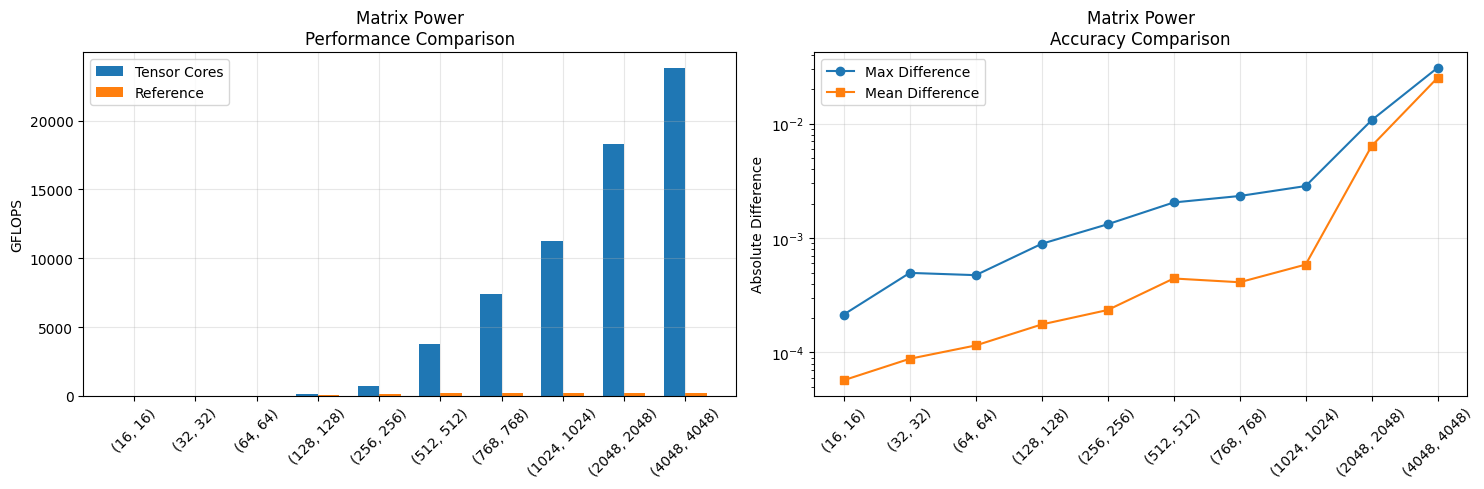

In [2]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps
# from benchmark_utils import run_benchmark

def test_matrix_power():
    """Benchmark matrix power operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Matrix Power"
    
    # Power to use for testing
    power = 4
    
    # Shapes to test (n×n matrices)
    shapes = [
        (16, 16),
        (32, 32),
        (64, 64),
        (128, 128),
        (256, 256),
        (512, 512),
        (768, 768),
        (1024, 1024),
        (2048, 2048),
        (4048, 4048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create a random matrix in Fortran order for matrix power."""
        a = cp.asfortranarray(cp.random.random(shape, dtype=cp.float64))
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(shape[0]) * 1.1)
        return [a, power]  # Return as list for unpacking
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for matrix power operation."""
        n = shape[0]
        # matrix_dot's power-of-two path does log2(p) squarings, not p-1
        # multiplies: p=4 is A^2 then (A^2)^2 = 2 GEMMs. The earlier
        # formula counted 3 and over-reported GFLOPS by 1.5x (2026-09-18).
        num_gemms = power.bit_length() - 1 if power & (power - 1) == 0 else power - 1
        return 2 * n * n * n * num_gemms
    
    # Define tensor operation
    def tensor_op(a, p):
        return tensor_ops.matrix_power(a, p)
    
    # Define reference operation
    def reference_op(a, p):
        return cp.linalg.matrix_power(a, p)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_power_results = test_matrix_power()
cleanup()
# CuPy 14 did not help except in batched operations; but there seems to be a 160 GFLOP ceiling (cannot reach 24 TFLOPS)

In [3]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


148

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Matrix Power [Rust]...
Warming up GPU...

Shape: (16, 16)

Shape: (32, 32)

Shape: (64, 64)

Shape: (128, 128)

Shape: (256, 256)

Shape: (512, 512)

Shape: (768, 768)

Shape: (1024, 1024)

Shape: (2048, 2048)

Shape: (4048, 4048)

Results for Matrix Power [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16)                             0.22            0.11         1.91     1.64e-04     5.12e-05
(32, 32)                             1.70            0.95         1.79     4.14e-04     7.33e-05
(64, 64)                            14.33            7.20         1.99     5.86e-04     1.28e-04
(128, 128)                         123.80           53.17         2.33     9.92e-04     1.73e-04
(256, 256)                         873.23        

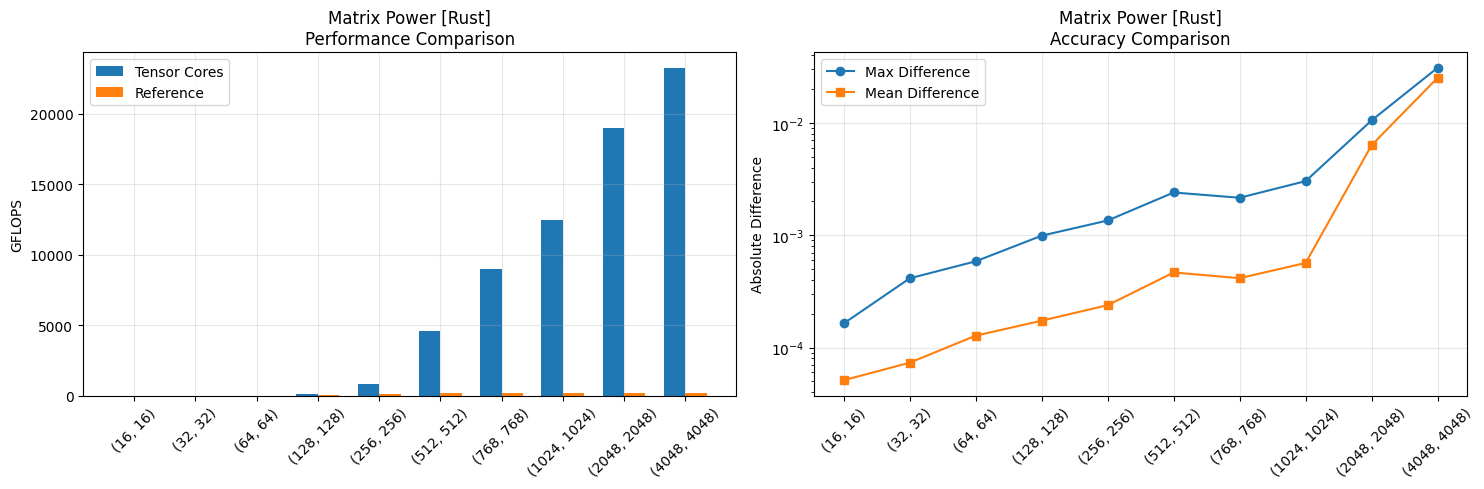

In [4]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps
# from benchmark_utils import run_benchmark

def test_matrix_power():
    """Benchmark matrix power operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Matrix Power [Rust]"
    
    # Power to use for testing
    power = 4
    
    # Shapes to test (n×n matrices)
    shapes = [
        (16, 16),
        (32, 32),
        (64, 64),
        (128, 128),
        (256, 256),
        (512, 512),
        (768, 768),
        (1024, 1024),
        (2048, 2048),
        (4048, 4048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create a random matrix in Fortran order for matrix power."""
        a = cp.asfortranarray(cp.random.random(shape, dtype=cp.float64))
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(shape[0]) * 1.1)
        return [a, power]  # Return as list for unpacking
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for matrix power operation."""
        n = shape[0]
        # matrix_dot's power-of-two path does log2(p) squarings, not p-1
        # multiplies: p=4 is A^2 then (A^2)^2 = 2 GEMMs. The earlier
        # formula counted 3 and over-reported GFLOPS by 1.5x (2026-09-18).
        num_gemms = power.bit_length() - 1 if power & (power - 1) == 0 else power - 1
        return 2 * n * n * n * num_gemms
    
    # Define tensor operation
    def tensor_op(a, p):
        return tensor_ops.matrix_power(a, p)
    
    # Define reference operation
    def reference_op(a, p):
        return cp.linalg.matrix_power(a, p)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_power_results_rust = test_matrix_power()
cleanup()
# CuPy 14 did not help except in batched operations; but there seems to be a 160 GFLOP ceiling (cannot reach 24 TFLOPS)

In [5]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured
Warming up GPU...

     N       TF32  tc_split    impr32      FP64   tc/FP64  i32/FP64    TF32 err     tc err    i32 err
-----------------------------------------------------------------------------------------------------
   128       45G      39G      27G      45G     0.86x     0.59x    3.03e-04   1.54e-07   1.62e-07
   256      338G     273G     175G     119G     2.30x     1.47x    3.07e-04   2.10e-07   2.08e-07
   512     2075G    1292G     680G     195G     6.62x     3.48x    2.71e-04   3.37e-07   3.32e-07
  1024     5709G    2689G    1209G     221G    12.15x     5.46x    2.82e-04   2.98e-07   2.90e-07
  2048     9479G    3775G    1384G     219G    17.20x     6.31x    2.89e-04   1.90e-06   1.89e-06
  4096    15044G    4355G    1458G     226G    19.27x     6.45x    3.10e-04   3.19e-06   3.19e-06

tc/FP64  : speedup of matmul_tc_split vs stock FP64
i32/FP64 : speedup of improved_matmul32 vs stock FP64
E

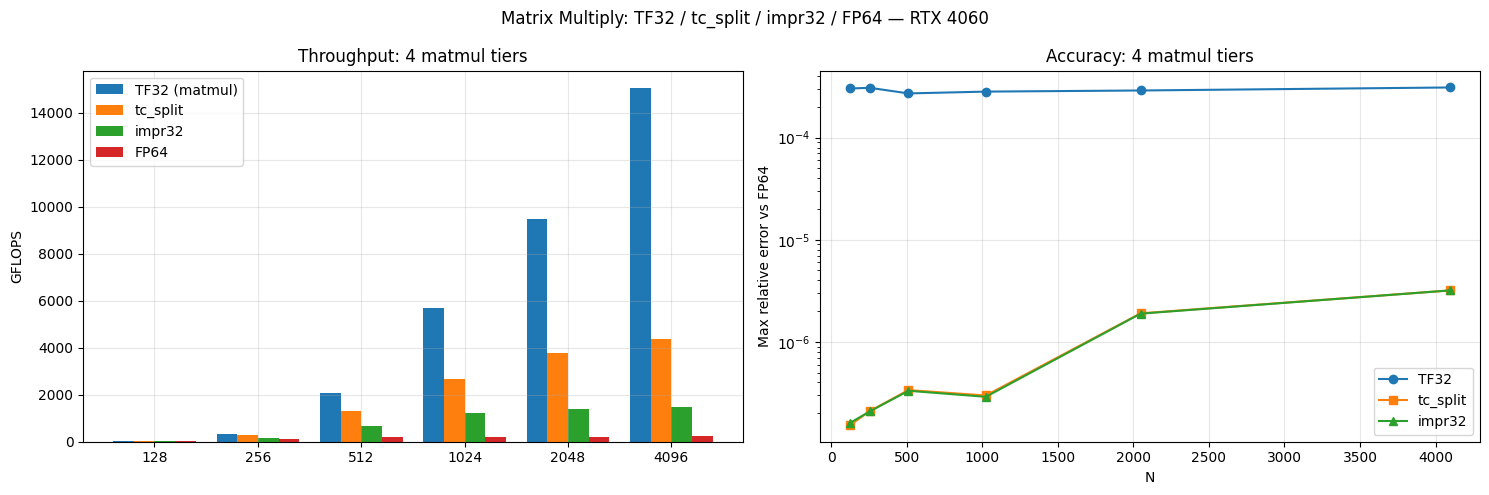

In [6]:
# Matrix Multiply: 4-tier comparison
#
# Tier 1 - TF32  (matmul):             FP64->TF32->FP64, tensor cores.
#                                       ~10-bit mantissa; ~1e-3 to 1e-5 rel err.
#                                       Fastest: ~30-35 TFLOPS on RTX 4060.
#
# Tier 2 - tc_split (matmul_tc_split): Ozaki 3-GEMM split.
#                                       T1=Ah*Bh exact-FP32 (CUDA cores) +
#                                       T2=Ah*Bl + T3=Al*Bh TF32 (tensor cores).
#                                       ~1e-6 rel err; ~3x faster than FP64.
#
# Tier 3 - impr32 (improved_matmul32): Ozaki 5x exact-FP32 GEMMs, FP64 accum.
#                                       ~1e-7 rel err; ~6x faster than FP64.
#
# Tier 4 - FP64   (cp.matmul):         Stock cuBLAS Dgemm, ~1e-14 rel err.
#                                       Baseline. CUDA cores only on consumer GPU.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

REPEAT = 5
WARMUP = 2

def _min_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Device().synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.Device().synchronize()
        t0 = time.perf_counter()
        fn(*args)
        cp.cuda.Device().synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return min(times)

shapes = [128, 256, 512, 1024, 2048, 4096]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Device().synchronize()
print()

hdr = (f"{'N':>6}  {'TF32':>9} {'tc_split':>9} {'impr32':>9} {'FP64':>9}  "
       f"{'tc/FP64':>8} {'i32/FP64':>9}  {'TF32 err':>10} {'tc err':>10} {'i32 err':>10}")
print(hdr)
print("-" * len(hdr))

rows = []
for N in shapes:
    rng = cp.random.default_rng(42)
    A = cp.asfortranarray(rng.standard_normal((N, N), dtype=cp.float64)) / (N**0.5 * 1.1)
    B = cp.asfortranarray(rng.standard_normal((N, N), dtype=cp.float64)) / (N**0.5 * 1.1)
    ref = cp.matmul(A, B)
    flops = 2 * N**3

    t_tf32  = _min_ms(ops.matmul, A, B)
    t_tcs   = _min_ms(ops.matmul_tc_split, A, B)
    t_i32   = _min_ms(ops.improved_matmul32, A, B)
    t_fp64  = _min_ms(cp.matmul, A, B)

    gf_tf32 = flops / (t_tf32  * 1e6)
    gf_tcs  = flops / (t_tcs   * 1e6)
    gf_i32  = flops / (t_i32   * 1e6)
    gf_fp64 = flops / (t_fp64  * 1e6)

    r_tf32 = ops.matmul(A, B)
    r_tcs  = ops.matmul_tc_split(A, B)
    r_i32  = ops.improved_matmul32(A, B)
    denom  = float(cp.max(cp.abs(ref)))
    err_tf32 = float(cp.max(cp.abs(r_tf32 - ref))) / denom
    err_tcs  = float(cp.max(cp.abs(r_tcs  - ref))) / denom
    err_i32  = float(cp.max(cp.abs(r_i32  - ref))) / denom

    print(f"{N:>6}  {gf_tf32:>7.0f}G {gf_tcs:>7.0f}G {gf_i32:>7.0f}G {gf_fp64:>7.0f}G  "
          f"{t_fp64/t_tcs:>7.2f}x {t_fp64/t_i32:>8.2f}x  "
          f"{err_tf32:>10.2e} {err_tcs:>10.2e} {err_i32:>10.2e}")

    rows.append(dict(N=N, gf_tf32=gf_tf32, gf_tcs=gf_tcs, gf_i32=gf_i32, gf_fp64=gf_fp64,
                     err_tf32=err_tf32, err_tcs=err_tcs, err_i32=err_i32,
                     sp_tcs=t_fp64/t_tcs, sp_i32=t_fp64/t_i32))

    del A, B, ref, r_tf32, r_tcs, r_i32
    cp.get_default_memory_pool().free_all_blocks()

print()
print("tc/FP64  : speedup of matmul_tc_split vs stock FP64")
print("i32/FP64 : speedup of improved_matmul32 vs stock FP64")
print("Errors are max relative error vs cp.matmul (FP64 reference)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
Ns = [r["N"] for r in rows]
x  = np.arange(len(Ns))
w  = 0.2

ax1.bar(x - 1.5*w, [r["gf_tf32"] for r in rows], w, label="TF32 (matmul)")
ax1.bar(x - 0.5*w, [r["gf_tcs"]  for r in rows], w, label="tc_split")
ax1.bar(x + 0.5*w, [r["gf_i32"]  for r in rows], w, label="impr32")
ax1.bar(x + 1.5*w, [r["gf_fp64"] for r in rows], w, label="FP64")
ax1.set_ylabel("GFLOPS")
ax1.set_title("Throughput: 4 matmul tiers")
ax1.set_xticks(x); ax1.set_xticklabels([str(n) for n in Ns])
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(Ns, [r["err_tf32"] for r in rows], "o-", label="TF32")
ax2.plot(Ns, [r["err_tcs"]  for r in rows], "s-", label="tc_split")
ax2.plot(Ns, [r["err_i32"]  for r in rows], "^-", label="impr32")
ax2.set_yscale("log")
ax2.set_ylabel("Max relative error vs FP64")
ax2.set_title("Accuracy: 4 matmul tiers")
ax2.set_xlabel("N")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("Matrix Multiply: TF32 / tc_split / impr32 / FP64 — RTX 4060")
plt.tight_layout()
plt.savefig("fig_matmul_4tier.png", dpi=150, bbox_inches="tight")
plt.show()
cleanup()


# Stubs for summary cell compatibility
improved_matmul32_results = []
improved_matmul64_results = []


In [7]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

Warming up GPU...

     N       TF32  tc_split    impr32      FP64   tc/FP64  i32/FP64    TF32 err     tc err    i32 err
-----------------------------------------------------------------------------------------------------
   128       89G      57G      62G      46G     1.25x     1.34x    3.03e-04   1.54e-07   1.62e-07
   256      659G     391G     366G     118G     3.30x     3.10x    3.07e-04   2.10e-07   2.08e-07
   512     3503G    1426G     903G     194G     7.33x     4.64x    2.71e-04   3.37e-07   3.32e-07
  1024     8160G    3102G    1312G     223G    13.93x     5.89x    2.82e-04   2.98e-07   2.90e-07
  2048    13708G    4119G    1481G     219G    18.79x     6.76x    2.89e-04   1.90e-06   1.89e-06
  4096    19875G    4523G    1495G     226G    20.01x     6.62x    3.10e-04   3.19e-06   3.19e-06

tc/FP64  : speedup of matmul_tc_split vs stock FP64
i32/FP64 : speedup of improved_matmul32 vs stock FP64
Errors are max relative error vs cp.matmul (FP64 reference)


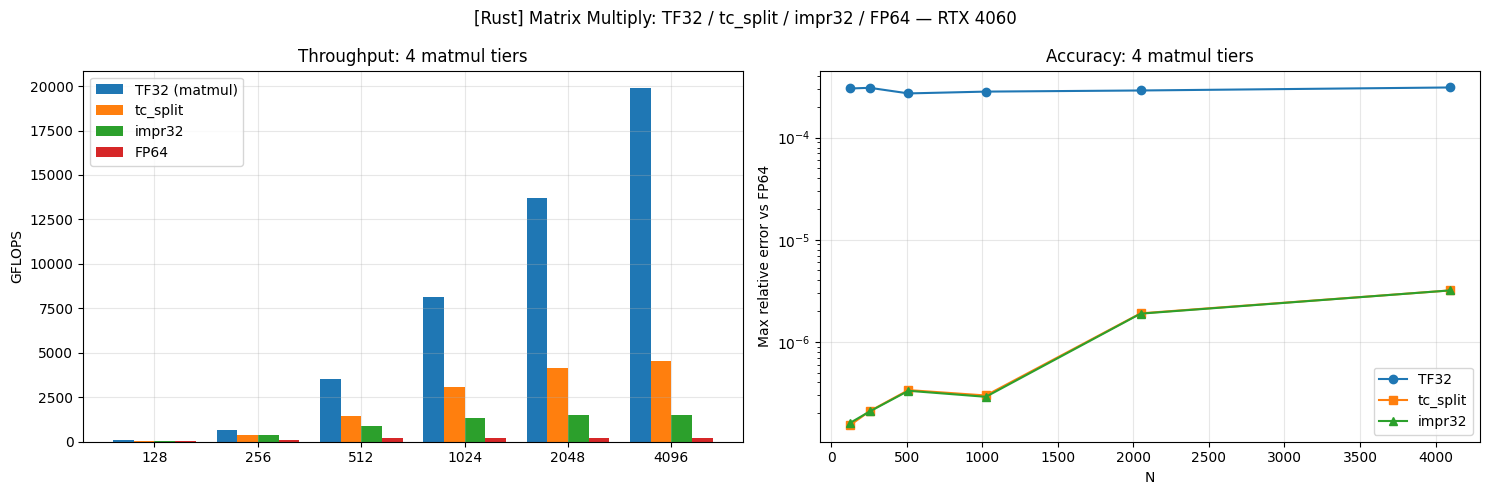

In [8]:
# Matrix Multiply: 4-tier comparison
#
# Tier 1 - TF32  (matmul):             FP64->TF32->FP64, tensor cores.
#                                       ~10-bit mantissa; ~1e-3 to 1e-5 rel err.
#                                       Fastest: ~30-35 TFLOPS on RTX 4060.
#
# Tier 2 - tc_split (matmul_tc_split): Ozaki 3-GEMM split.
#                                       T1=Ah*Bh exact-FP32 (CUDA cores) +
#                                       T2=Ah*Bl + T3=Al*Bh TF32 (tensor cores).
#                                       ~1e-6 rel err; ~3x faster than FP64.
#
# Tier 3 - impr32 (improved_matmul32): Ozaki 5x exact-FP32 GEMMs, FP64 accum.
#                                       ~1e-7 rel err; ~6x faster than FP64.
#
# Tier 4 - FP64   (cp.matmul):         Stock cuBLAS Dgemm, ~1e-14 rel err.
#                                       Baseline. CUDA cores only on consumer GPU.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from rust_matrix_ops import RustMatrixOps

ops = RustMatrixOps()

REPEAT = 5
WARMUP = 2

def _min_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Device().synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.Device().synchronize()
        t0 = time.perf_counter()
        fn(*args)
        cp.cuda.Device().synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return min(times)

shapes = [128, 256, 512, 1024, 2048, 4096]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Device().synchronize()
print()

hdr = (f"{'N':>6}  {'TF32':>9} {'tc_split':>9} {'impr32':>9} {'FP64':>9}  "
       f"{'tc/FP64':>8} {'i32/FP64':>9}  {'TF32 err':>10} {'tc err':>10} {'i32 err':>10}")
print(hdr)
print("-" * len(hdr))

rows = []
for N in shapes:
    rng = cp.random.default_rng(42)
    A = cp.asfortranarray(rng.standard_normal((N, N), dtype=cp.float64)) / (N**0.5 * 1.1)
    B = cp.asfortranarray(rng.standard_normal((N, N), dtype=cp.float64)) / (N**0.5 * 1.1)
    ref = cp.matmul(A, B)
    flops = 2 * N**3

    t_tf32  = _min_ms(ops.matmul, A, B)
    t_tcs   = _min_ms(ops.matmul_tc_split, A, B)
    t_i32   = _min_ms(ops.improved_matmul32, A, B)
    t_fp64  = _min_ms(cp.matmul, A, B)

    gf_tf32 = flops / (t_tf32  * 1e6)
    gf_tcs  = flops / (t_tcs   * 1e6)
    gf_i32  = flops / (t_i32   * 1e6)
    gf_fp64 = flops / (t_fp64  * 1e6)

    r_tf32 = ops.matmul(A, B)
    r_tcs  = ops.matmul_tc_split(A, B)
    r_i32  = ops.improved_matmul32(A, B)
    denom  = float(cp.max(cp.abs(ref)))
    err_tf32 = float(cp.max(cp.abs(r_tf32 - ref))) / denom
    err_tcs  = float(cp.max(cp.abs(r_tcs  - ref))) / denom
    err_i32  = float(cp.max(cp.abs(r_i32  - ref))) / denom

    print(f"{N:>6}  {gf_tf32:>7.0f}G {gf_tcs:>7.0f}G {gf_i32:>7.0f}G {gf_fp64:>7.0f}G  "
          f"{t_fp64/t_tcs:>7.2f}x {t_fp64/t_i32:>8.2f}x  "
          f"{err_tf32:>10.2e} {err_tcs:>10.2e} {err_i32:>10.2e}")

    rows.append(dict(N=N, gf_tf32=gf_tf32, gf_tcs=gf_tcs, gf_i32=gf_i32, gf_fp64=gf_fp64,
                     err_tf32=err_tf32, err_tcs=err_tcs, err_i32=err_i32,
                     sp_tcs=t_fp64/t_tcs, sp_i32=t_fp64/t_i32))

    del A, B, ref, r_tf32, r_tcs, r_i32
    cp.get_default_memory_pool().free_all_blocks()

print()
print("tc/FP64  : speedup of matmul_tc_split vs stock FP64")
print("i32/FP64 : speedup of improved_matmul32 vs stock FP64")
print("Errors are max relative error vs cp.matmul (FP64 reference)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
Ns = [r["N"] for r in rows]
x  = np.arange(len(Ns))
w  = 0.2

ax1.bar(x - 1.5*w, [r["gf_tf32"] for r in rows], w, label="TF32 (matmul)")
ax1.bar(x - 0.5*w, [r["gf_tcs"]  for r in rows], w, label="tc_split")
ax1.bar(x + 0.5*w, [r["gf_i32"]  for r in rows], w, label="impr32")
ax1.bar(x + 1.5*w, [r["gf_fp64"] for r in rows], w, label="FP64")
ax1.set_ylabel("GFLOPS")
ax1.set_title("Throughput: 4 matmul tiers")
ax1.set_xticks(x); ax1.set_xticklabels([str(n) for n in Ns])
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(Ns, [r["err_tf32"] for r in rows], "o-", label="TF32")
ax2.plot(Ns, [r["err_tcs"]  for r in rows], "s-", label="tc_split")
ax2.plot(Ns, [r["err_i32"]  for r in rows], "^-", label="impr32")
ax2.set_yscale("log")
ax2.set_ylabel("Max relative error vs FP64")
ax2.set_title("Accuracy: 4 matmul tiers")
ax2.set_xlabel("N")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("[Rust] Matrix Multiply: TF32 / tc_split / impr32 / FP64 — RTX 4060")
plt.tight_layout()
plt.savefig("fig_matmul_4tier_rust.png", dpi=150, bbox_inches="tight")
plt.show()
cleanup()


# Stubs for summary cell compatibility
improved_matmul32_results = []
improved_matmul64_results = []


In [9]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

While improved_matmul32 benefits from tensor cores, FP64 operations are stuck with CUDA on consumer hardware like the RTX4060. So we are using stock FP64 for applications that need accuracy. Split precision operations for FP64 call FP64 CUDA 3x, resulting in a slowdown not a speedup!



Initializing CUDA...
CUDA initialization complete
Function signatures configured
Warming up GPU...

Shape                 TF32  tc_split      FP64   tc/FP64    TF32 err     tc err
-------------------------------------------------------------------------------
(8, 64^3)             50G      45G      67G     0.67x    3.75e-04   2.66e-07
(8, 128^3)           322G     282G     169G     1.67x    3.41e-04   4.27e-07
(8, 256^3)          1525G    1003G     217G     4.62x    3.06e-04   7.68e-07
(8, 512^3)          3728G    2083G     226G     9.23x    3.32e-04   1.06e-06
(8, 1024^3)         5404G    3301G     226G    14.62x    3.04e-04   1.52e-06
(8, 2048^3)         7987G    3969G     226G    17.53x    2.84e-04   2.16e-06

tc/FP64  : speedup of batched_matmul_tc_split vs batched_matmul_fp64
TF32 err : max relative error of batched_matmul vs FP64 reference
tc err   : max relative error of batched_matmul_tc_split vs FP64 reference


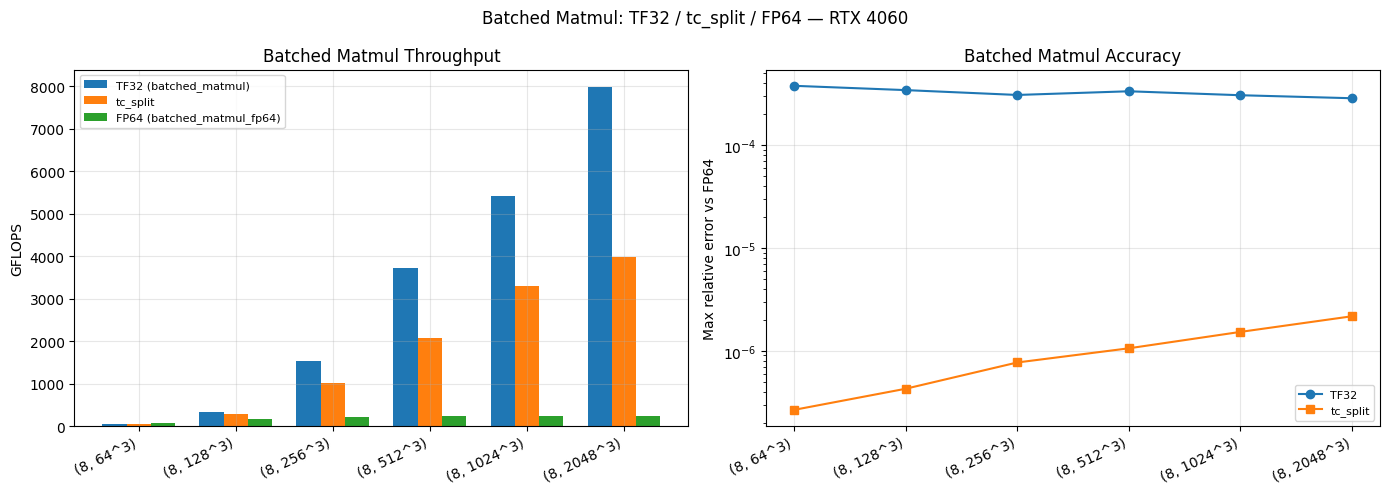

In [10]:
# [v5] Batched matmul: TF32 / tc_split / FP64 — 3-tier comparison
#
# tc_split (batched_matmul_tc_split): Ozaki 3-GEMM scheme applied to strided batched GEMM.
#   T1=Ah*Bh exact-FP32 (CUDA cores) + T2=Ah*Bl + T3=Al*Bh TF32 (tensor cores).
#   C = FP64(T1) + FP64(T2) + FP64(T3).
#   Accuracy ~1e-6; speed ~3-5x faster than FP64.
#
# Fused ops note: batched_matmul_bias_relu uses cuBLAS-lt epilogue fusion (bias+relu
# run inside GEMM output registers). This requires a single monolithic GEMM and cannot
# be applied to the 3-GEMM tc_split path. Use tc_split when FP32-level accuracy is
# needed without bias/relu fusion.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

REPEAT = 10
WARMUP = 3

def _min_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        fn(*args)
        cp.cuda.Stream.null.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return min(times)

shapes = [
    ("(8, 64^3)",    8,   64,   64,   64),
    ("(8, 128^3)",   8,  128,  128,  128),
    ("(8, 256^3)",   8,  256,  256,  256),
    ("(8, 512^3)",   8,  512,  512,  512),
    ("(8, 1024^3)",  8, 1024, 1024, 1024),
    ("(8, 2048^3)",  8, 2048, 2048, 2048),
]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Stream.null.synchronize()
print()

hdr = (f"{'Shape':<16} {'TF32':>9} {'tc_split':>9} {'FP64':>9}  "
       f"{'tc/FP64':>8}  {'TF32 err':>10} {'tc err':>10}")
print(hdr)
print("-" * len(hdr))

rows = []
for label, batch, m, k, n in shapes:
    rng = cp.random.default_rng(0)
    A = cp.ascontiguousarray(rng.standard_normal((batch, m, k), dtype=cp.float64)) / (k**0.5 * 1.1)
    B = cp.ascontiguousarray(rng.standard_normal((batch, k, n), dtype=cp.float64)) / (k**0.5 * 1.1)
    ref = cp.matmul(A, B)
    flops = 2 * batch * m * k * n

    t_tf32 = _min_ms(ops.batched_matmul,          A, B)
    t_tcs  = _min_ms(ops.batched_matmul_tc_split, A, B)
    t_fp64 = _min_ms(ops.batched_matmul_fp64,     A, B)

    gf_tf32 = flops / (t_tf32 * 1e6)
    gf_tcs  = flops / (t_tcs  * 1e6)
    gf_fp64 = flops / (t_fp64 * 1e6)

    denom    = float(cp.max(cp.abs(ref)))
    err_tf32 = float(cp.max(cp.abs(ops.batched_matmul(A, B)          - ref))) / denom
    err_tcs  = float(cp.max(cp.abs(ops.batched_matmul_tc_split(A, B) - ref))) / denom

    print(f"{label:<16} {gf_tf32:>7.0f}G {gf_tcs:>7.0f}G {gf_fp64:>7.0f}G  "
          f"{t_fp64/t_tcs:>7.2f}x  {err_tf32:>10.2e} {err_tcs:>10.2e}")

    rows.append(dict(label=label, gf_tf32=gf_tf32, gf_tcs=gf_tcs, gf_fp64=gf_fp64,
                     err_tf32=err_tf32, err_tcs=err_tcs, sp_tcs=t_fp64/t_tcs))

    del A, B, ref
    cp.get_default_memory_pool().free_all_blocks()

print()
print("tc/FP64  : speedup of batched_matmul_tc_split vs batched_matmul_fp64")
print("TF32 err : max relative error of batched_matmul vs FP64 reference")
print("tc err   : max relative error of batched_matmul_tc_split vs FP64 reference")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels = [r["label"] for r in rows]
x = np.arange(len(labels))
w = 0.25

ax1.bar(x - w, [r["gf_tf32"] for r in rows], w, label="TF32 (batched_matmul)")
ax1.bar(x,     [r["gf_tcs"]  for r in rows], w, label="tc_split")
ax1.bar(x + w, [r["gf_fp64"] for r in rows], w, label="FP64 (batched_matmul_fp64)")
ax1.set_ylabel("GFLOPS")
ax1.set_title("Batched Matmul Throughput")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.plot(labels, [r["err_tf32"] for r in rows], "o-", label="TF32")
ax2.plot(labels, [r["err_tcs"]  for r in rows], "s-", label="tc_split")
ax2.set_yscale("log")
ax2.set_ylabel("Max relative error vs FP64")
ax2.set_title("Batched Matmul Accuracy")
ax2.set_xticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation=25, ha="right")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle("Batched Matmul: TF32 / tc_split / FP64 — RTX 4060")
plt.tight_layout()
plt.savefig("fig_batched_matmul_4tier.png", dpi=150, bbox_inches="tight")
plt.show()
cleanup()


In [11]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

Warming up GPU...

Shape                 TF32  tc_split      FP64   tc/FP64    TF32 err     tc err
-------------------------------------------------------------------------------
(8, 64^3)             64G      46G      63G     0.73x    3.75e-04   2.66e-07
(8, 128^3)           434G     265G     165G     1.60x    3.41e-04   4.27e-07
(8, 256^3)          2607G    1096G     216G     5.06x    3.06e-04   7.68e-07
(8, 512^3)          4977G    2167G     228G     9.51x    3.32e-04   1.06e-06
(8, 1024^3)         8862G    3315G     226G    14.67x    3.04e-04   1.52e-06
(8, 2048^3)        13214G    4113G     227G    18.13x    2.84e-04   2.16e-06

tc/FP64  : speedup of batched_matmul_tc_split vs batched_matmul_fp64
TF32 err : max relative error of batched_matmul vs FP64 reference
tc err   : max relative error of batched_matmul_tc_split vs FP64 reference


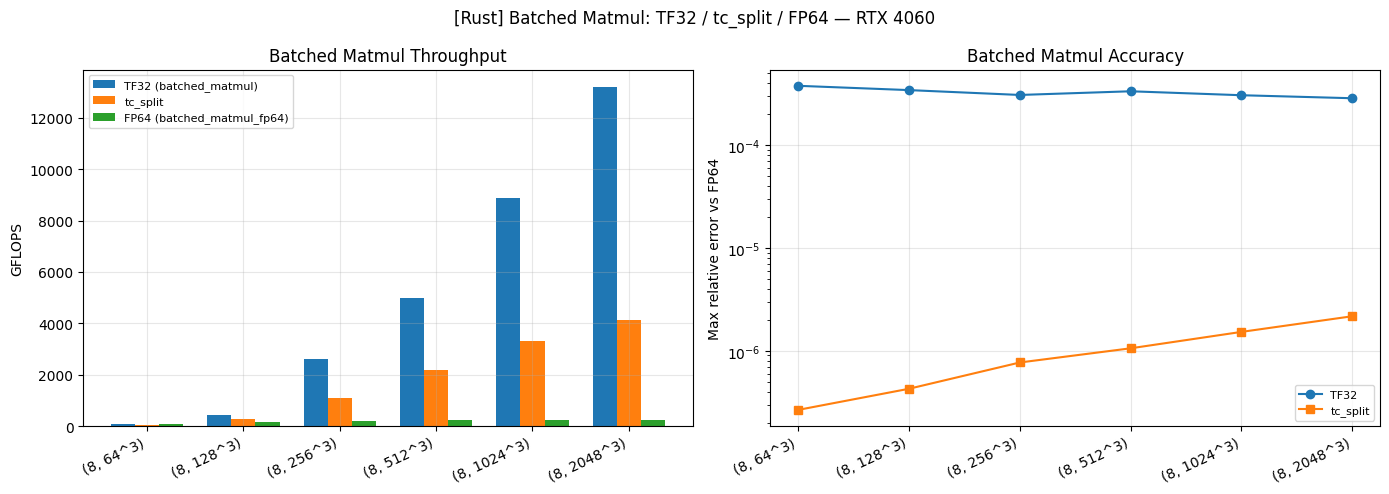

In [12]:
# [v5] Batched matmul: TF32 / tc_split / FP64 — 3-tier comparison
#
# tc_split (batched_matmul_tc_split): Ozaki 3-GEMM scheme applied to strided batched GEMM.
#   T1=Ah*Bh exact-FP32 (CUDA cores) + T2=Ah*Bl + T3=Al*Bh TF32 (tensor cores).
#   C = FP64(T1) + FP64(T2) + FP64(T3).
#   Accuracy ~1e-6; speed ~3-5x faster than FP64.
#
# Fused ops note: batched_matmul_bias_relu uses cuBLAS-lt epilogue fusion (bias+relu
# run inside GEMM output registers). This requires a single monolithic GEMM and cannot
# be applied to the 3-GEMM tc_split path. Use tc_split when FP32-level accuracy is
# needed without bias/relu fusion.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from rust_matrix_ops import RustMatrixOps

ops = RustMatrixOps()

REPEAT = 10
WARMUP = 3

def _min_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        fn(*args)
        cp.cuda.Stream.null.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return min(times)

shapes = [
    ("(8, 64^3)",    8,   64,   64,   64),
    ("(8, 128^3)",   8,  128,  128,  128),
    ("(8, 256^3)",   8,  256,  256,  256),
    ("(8, 512^3)",   8,  512,  512,  512),
    ("(8, 1024^3)",  8, 1024, 1024, 1024),
    ("(8, 2048^3)",  8, 2048, 2048, 2048),
]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Stream.null.synchronize()
print()

hdr = (f"{'Shape':<16} {'TF32':>9} {'tc_split':>9} {'FP64':>9}  "
       f"{'tc/FP64':>8}  {'TF32 err':>10} {'tc err':>10}")
print(hdr)
print("-" * len(hdr))

rows = []
for label, batch, m, k, n in shapes:
    rng = cp.random.default_rng(0)
    A = cp.ascontiguousarray(rng.standard_normal((batch, m, k), dtype=cp.float64)) / (k**0.5 * 1.1)
    B = cp.ascontiguousarray(rng.standard_normal((batch, k, n), dtype=cp.float64)) / (k**0.5 * 1.1)
    ref = cp.matmul(A, B)
    flops = 2 * batch * m * k * n

    t_tf32 = _min_ms(ops.batched_matmul,          A, B)
    t_tcs  = _min_ms(ops.batched_matmul_tc_split, A, B)
    t_fp64 = _min_ms(ops.batched_matmul_fp64,     A, B)

    gf_tf32 = flops / (t_tf32 * 1e6)
    gf_tcs  = flops / (t_tcs  * 1e6)
    gf_fp64 = flops / (t_fp64 * 1e6)

    denom    = float(cp.max(cp.abs(ref)))
    err_tf32 = float(cp.max(cp.abs(ops.batched_matmul(A, B)          - ref))) / denom
    err_tcs  = float(cp.max(cp.abs(ops.batched_matmul_tc_split(A, B) - ref))) / denom

    print(f"{label:<16} {gf_tf32:>7.0f}G {gf_tcs:>7.0f}G {gf_fp64:>7.0f}G  "
          f"{t_fp64/t_tcs:>7.2f}x  {err_tf32:>10.2e} {err_tcs:>10.2e}")

    rows.append(dict(label=label, gf_tf32=gf_tf32, gf_tcs=gf_tcs, gf_fp64=gf_fp64,
                     err_tf32=err_tf32, err_tcs=err_tcs, sp_tcs=t_fp64/t_tcs))

    del A, B, ref
    cp.get_default_memory_pool().free_all_blocks()

print()
print("tc/FP64  : speedup of batched_matmul_tc_split vs batched_matmul_fp64")
print("TF32 err : max relative error of batched_matmul vs FP64 reference")
print("tc err   : max relative error of batched_matmul_tc_split vs FP64 reference")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels = [r["label"] for r in rows]
x = np.arange(len(labels))
w = 0.25

ax1.bar(x - w, [r["gf_tf32"] for r in rows], w, label="TF32 (batched_matmul)")
ax1.bar(x,     [r["gf_tcs"]  for r in rows], w, label="tc_split")
ax1.bar(x + w, [r["gf_fp64"] for r in rows], w, label="FP64 (batched_matmul_fp64)")
ax1.set_ylabel("GFLOPS")
ax1.set_title("Batched Matmul Throughput")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.plot(labels, [r["err_tf32"] for r in rows], "o-", label="TF32")
ax2.plot(labels, [r["err_tcs"]  for r in rows], "s-", label="tc_split")
ax2.set_yscale("log")
ax2.set_ylabel("Max relative error vs FP64")
ax2.set_title("Batched Matmul Accuracy")
ax2.set_xticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation=25, ha="right")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle("[Rust] Batched Matmul: TF32 / tc_split / FP64 — RTX 4060")
plt.tight_layout()
plt.savefig("fig_batched_matmul_4tier_rust.png", dpi=150, bbox_inches="tight")
plt.show()
cleanup()


In [13]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Matrix Multiplication...
Warming up GPU...

Shape: (16, 16, 16)

Shape: (32, 32, 32)

Shape: (64, 64, 64)

Shape: (128, 128, 128)

Shape: (256, 256, 256)

Shape: (512, 512, 512)

Shape: (640, 640, 640)

Shape: (1024, 1024, 1024)

Shape: (2048, 2048, 2048)

Shape: (4048, 4048, 4048)

Results for Matrix Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16, 16)                         0.12            0.11         1.08     5.58e-05     1.69e-05
(32, 32, 32)                         1.17            0.82         1.42     6.68e-05     1.19e-05
(64, 64, 64)                         9.21            6.71         1.37     3.43e-05     7.61e-06
(128, 128, 

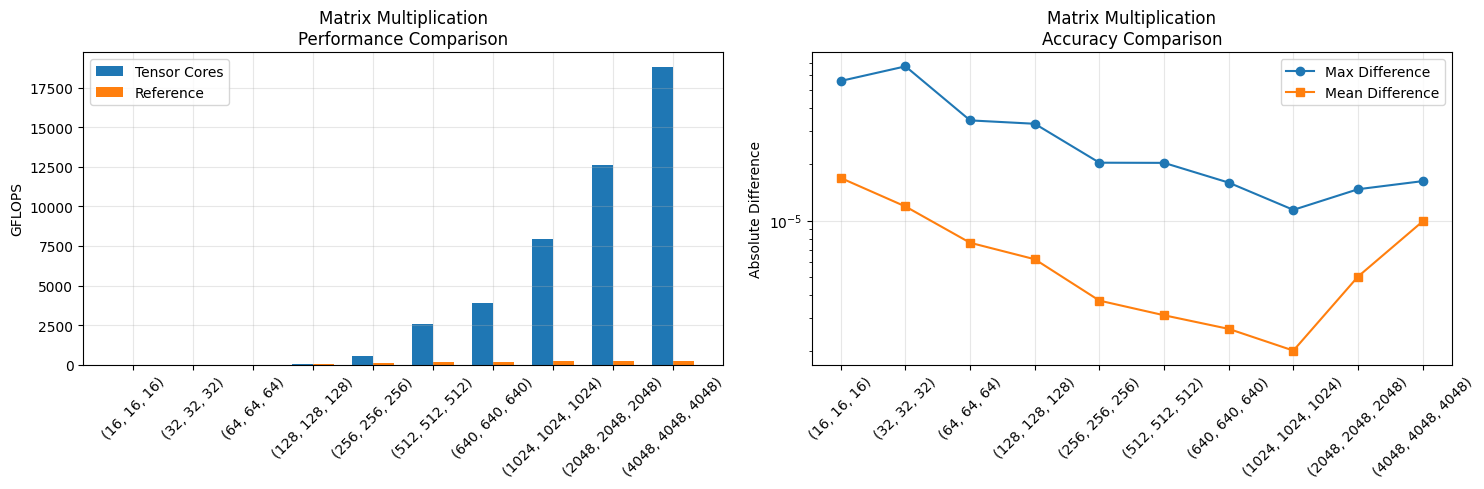

In [14]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps
# from benchmark_utils import run_benchmark

def test_matrix_multiply():
    """Benchmark matrix multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Matrix Multiplication"
    
    # Shapes to test
    shapes = [
        (16, 16, 16),   # (M, K, N)
        (32, 32, 32),
        (64, 64, 64),
        (128, 128, 128),
        (256, 256, 256),
        (512, 512, 512),
        (640, 640, 640),
        (1024, 1024, 1024),
        (2048, 2048, 2048),
        (4048, 4048, 4048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random matrices in Fortran order for matrix multiplication."""
        m, k, n = shape
        a = cp.asfortranarray(cp.random.random((m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        return [a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for matrix multiplication."""
        m, k, n = shape
        # Matrix multiplication requires 2*M*N*K FLOPS
        return 2 * m * n * k
    
    # Define tensor operation
    def tensor_op(a, b):
        return tensor_ops.matmul(a, b)
    
    # Define reference operation
    def reference_op(a, b):
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_multiply_results = test_matrix_multiply()
cleanup()

In [15]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Matrix Multiplication [Rust]...
Warming up GPU...

Shape: (16, 16, 16)

Shape: (32, 32, 32)

Shape: (64, 64, 64)

Shape: (128, 128, 128)

Shape: (256, 256, 256)

Shape: (512, 512, 512)

Shape: (640, 640, 640)

Shape: (1024, 1024, 1024)

Shape: (2048, 2048, 2048)

Shape: (4048, 4048, 4048)

Results for Matrix Multiplication [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 16, 16)                         0.14            0.11         1.26     4.95e-05     1.57e-05
(32, 32, 32)                         1.16            0.91         1.28     4.58e-05     1.12e-05
(64, 64, 64)                         9.60            6.65         1.44     3.88e-05     7.65e-06
(128, 128, 128)                     81.87           44.99         1.82     3.4

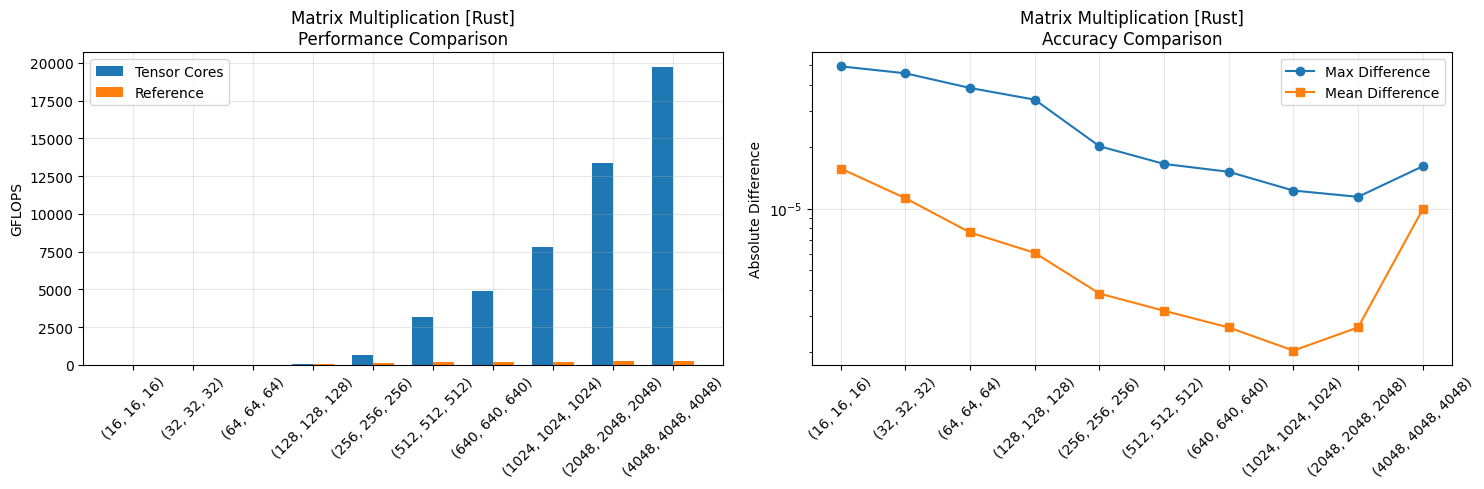

In [16]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps
# from benchmark_utils import run_benchmark

def test_matrix_multiply():
    """Benchmark matrix multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Matrix Multiplication [Rust]"
    
    # Shapes to test
    shapes = [
        (16, 16, 16),   # (M, K, N)
        (32, 32, 32),
        (64, 64, 64),
        (128, 128, 128),
        (256, 256, 256),
        (512, 512, 512),
        (640, 640, 640),
        (1024, 1024, 1024),
        (2048, 2048, 2048),
        (4048, 4048, 4048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random matrices in Fortran order for matrix multiplication."""
        m, k, n = shape
        a = cp.asfortranarray(cp.random.random((m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        return [a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for matrix multiplication."""
        m, k, n = shape
        # Matrix multiplication requires 2*M*N*K FLOPS
        return 2 * m * n * k
    
    # Define tensor operation
    def tensor_op(a, b):
        return tensor_ops.matmul(a, b)
    
    # Define reference operation
    def reference_op(a, b):
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_multiply_results_rust = test_matrix_multiply()
cleanup()

In [17]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured
Warming up GPU...

Shape                          Fused   Unfused      CuPy     F/U    F/C    Max err
----------------------------------------------------------------------------------
(8, 16³)                       1.1G     0.6G     0.6G   2.00x  2.05x   1.10e-07
(8, 32³)                       8.6G     4.4G     4.5G   1.96x  1.93x   1.38e-04
(8, 64³)                      66.7G    32.8G    35.4G   2.03x  1.88x   9.95e-05
(8, 128³)                    436.2G   225.8G   135.2G   1.93x  3.23x   8.42e-05
(8, 256³)                   1889.8G  1075.0G   206.4G   1.76x  9.16x   6.38e-05
(8, 1024³)                  4502.1G  4026.3G   222.5G   1.12x 20.24x   3.48e-05
(8, 2048³)                  6887.1G  6396.2G   223.6G   1.08x 30.81x   2.80e-05
fc1 (512×2048×128)          1701.1G  1358.5G   146.9G   1.25x 11.58x   2.22e-05
fc2 (256×512×128)            442.1G   249.2G   130.3G   1.77x  3.39x   4.83e-05
fc3 (10×256×12

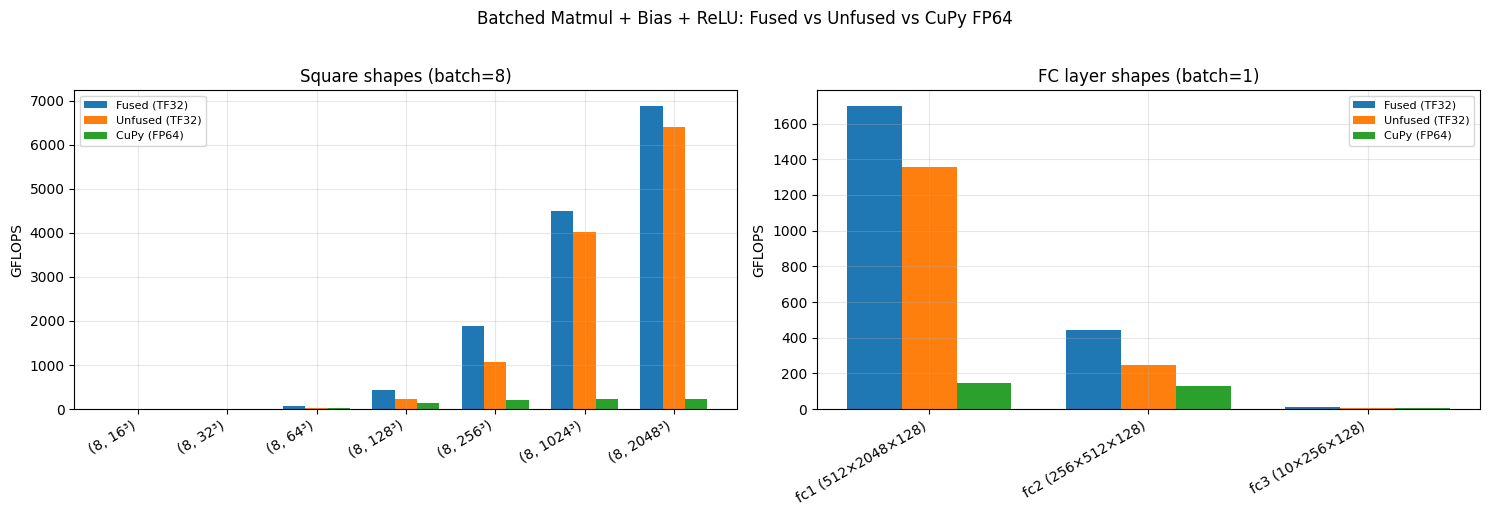

In [18]:
# [v5] Batched matrix multiply — unified three-way benchmark
#
# All shapes are tested against all three implementations so results are
# directly comparable:
#
#   fused    — batched_matmul_bias_relu  (cuBLAS-lt TF32, bias+relu in GEMM registers)
#   unfused  — batched_matmul + cp.maximum(C + bias, 0)  (cuBLAS TF32 + separate CuPy kernel)
#   cupy     — cp.maximum(cp.matmul(A, B) + bias, 0)     (cuBLAS FP64, reference baseline)
#
# A bias vector is added to all shapes so all three paths compute the same operation.
# Square shapes use batch=8; FC shapes use batch=1.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

REPEAT = 10
WARMUP = 3

def _min_time_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        result = fn(*args)
        cp.cuda.Stream.null.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return result, min(times)

# (label, batch, m, k, n)
shapes = [
    ("(8, 16³)",            8,   16,   16,   16),
    ("(8, 32³)",            8,   32,   32,   32),
    ("(8, 64³)",            8,   64,   64,   64),
    ("(8, 128³)",           8,  128,  128,  128),
    ("(8, 256³)",           8,  256,  256,  256),
    ("(8, 1024³)",          8, 1024, 1024, 1024),
    ("(8, 2048³)",          8, 2048, 2048, 2048),
    ("fc1 (512×2048×128)",  1,  512, 2048,  128),
    ("fc2 (256×512×128)",   1,  256,  512,  128),
    ("fc3 (10×256×128)",    1,   10,  256,  128),
]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Stream.null.synchronize()

print()
hdr = f"{'Shape':<26} {'Fused':>9} {'Unfused':>9} {'CuPy':>9}  {'F/U':>6} {'F/C':>6}  {'Max err':>9}"
print(hdr)
print("-" * len(hdr))

rows = []
for label, batch, m, k, n in shapes:
    rng = cp.random.default_rng(0)
    A    = cp.ascontiguousarray(rng.standard_normal((batch, m, k), dtype=cp.float64)) / (np.sqrt(k) * 1.1)
    B    = cp.ascontiguousarray(rng.standard_normal((batch, k, n), dtype=cp.float64)) / (np.sqrt(k) * 1.1)
    bias = rng.standard_normal(m, dtype=cp.float64)

    def fused(A, B, bias):
        return ops.batched_matmul_bias_relu(A, B, bias)

    def unfused(A, B, bias):
        C = ops.batched_matmul(A, B)
        return cp.maximum(C + bias[:, None], 0.0)

    def cupy_ref(A, B, bias):
        return cp.maximum(cp.matmul(A, B) + bias[:, None], 0.0)

    res_f, t_f = _min_time_ms(fused,    A, B, bias)
    res_u, t_u = _min_time_ms(unfused,  A, B, bias)
    res_c, t_c = _min_time_ms(cupy_ref, A, B, bias)

    flops     = 2 * batch * m * k * n
    gf_f      = flops / (t_f * 1e6)
    gf_u      = flops / (t_u * 1e6)
    gf_c      = flops / (t_c * 1e6)
    ratio_fu  = t_u / t_f
    ratio_fc  = t_c / t_f
    max_err   = float(cp.max(cp.abs(res_f[0] - res_c[0])))

    print(f"{label:<26} {gf_f:>7.1f}G {gf_u:>7.1f}G {gf_c:>7.1f}G  "
          f"{ratio_fu:>5.2f}x {ratio_fc:>5.2f}x  {max_err:>9.2e}")

    rows.append(dict(label=label, batch=batch, m=m, k=k, n=n,
                     gf_f=gf_f, gf_u=gf_u, gf_c=gf_c,
                     t_f=t_f, t_u=t_u, t_c=t_c,
                     ratio_fu=ratio_fu, ratio_fc=ratio_fc, max_err=max_err))

    del A, B, bias, res_f, res_u, res_c
    cp.get_default_memory_pool().free_all_blocks()

print()
print("Columns: Fused = batched_matmul_bias_relu (TF32), Unfused = batched_matmul + CuPy bias+relu (TF32),")
print("         CuPy  = cp.matmul + bias + relu (FP64).  F/U = fused speedup vs unfused. F/C = vs CuPy.")
print("Max err: fused vs CuPy FP64 — driven by TF32 GEMM rounding, not by fusion itself.")

# ── Split chart: square shapes (left) vs FC shapes (right) ──────────────────
# Different scales; FC shapes would be invisible on the same axis as (8, 2048³).
square_rows = [r for r in rows if r['batch'] == 8]
fc_rows     = [r for r in rows if r['batch'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, group, title in [
    (axes[0], square_rows, "Square shapes (batch=8)"),
    (axes[1], fc_rows,     "FC layer shapes (batch=1)"),
]:
    labels = [r['label'] for r in group]
    x = np.arange(len(labels))
    w = 0.25
    ax.bar(x - w, [r['gf_f'] for r in group], w, label='Fused (TF32)')
    ax.bar(x,     [r['gf_u'] for r in group], w, label='Unfused (TF32)')
    ax.bar(x + w, [r['gf_c'] for r in group], w, label='CuPy (FP64)')
    ax.set_ylabel('GFLOPS')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Batched Matmul + Bias + ReLU: Fused vs Unfused vs CuPy FP64', y=1.02)
plt.tight_layout()
plt.show()

# Retain variables for summary cell
batched_matmul_results = [
    dict(shape=(r['batch'], r['m'], r['k'], r['n']),
         tensor_gflops=r['gf_f'], reference_gflops=r['gf_c'],
         speedup=r['ratio_fc'], max_diff=r['max_err'], mean_diff=r['max_err'],
         tensor_times=[r['t_f']], reference_times=[r['t_c']])
    for r in rows if r['batch'] == 8
]
batched_matmul_fused_results = [
    dict(shape=(r['batch'], r['m'], r['k'], r['n']),
         tensor_gflops=r['gf_f'], reference_gflops=r['gf_c'],
         speedup=r['ratio_fc'], max_diff=r['max_err'], mean_diff=r['max_err'],
         tensor_times=[r['t_f']], reference_times=[r['t_c']])
    for r in rows if r['batch'] == 1
]


In [19]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


396

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

Warming up GPU...

Shape                          Fused   Unfused      CuPy     F/U    F/C    Max err
----------------------------------------------------------------------------------
(8, 16³)                       1.3G     0.6G     0.6G   2.16x  2.42x   1.56e-04
(8, 32³)                      10.7G     5.0G     4.5G   2.14x  2.39x   1.38e-04
(8, 64³)                      85.5G    39.2G    35.5G   2.18x  2.41x   9.95e-05
(8, 128³)                    602.6G   277.4G   135.4G   2.17x  4.45x   8.42e-05
(8, 256³)                   2469.2G  1449.4G   206.6G   1.70x 11.95x   6.38e-05
(8, 1024³)                  7077.9G  5692.0G   222.6G   1.24x 31.80x   3.48e-05
(8, 2048³)                  9252.8G  9294.8G   223.6G   1.00x 41.38x   2.80e-05
fc1 (512×2048×128)          2737.7G  1887.2G   192.7G   1.45x 14.20x   2.22e-05
fc2 (256×512×128)            610.6G   293.5G   130.3G   2.08x  4.69x   4.83e-05
fc3 (10×256×128)              12.6G     5.8G     5.6G   2.17x  2.23x   9.24e-08

Columns: Fused

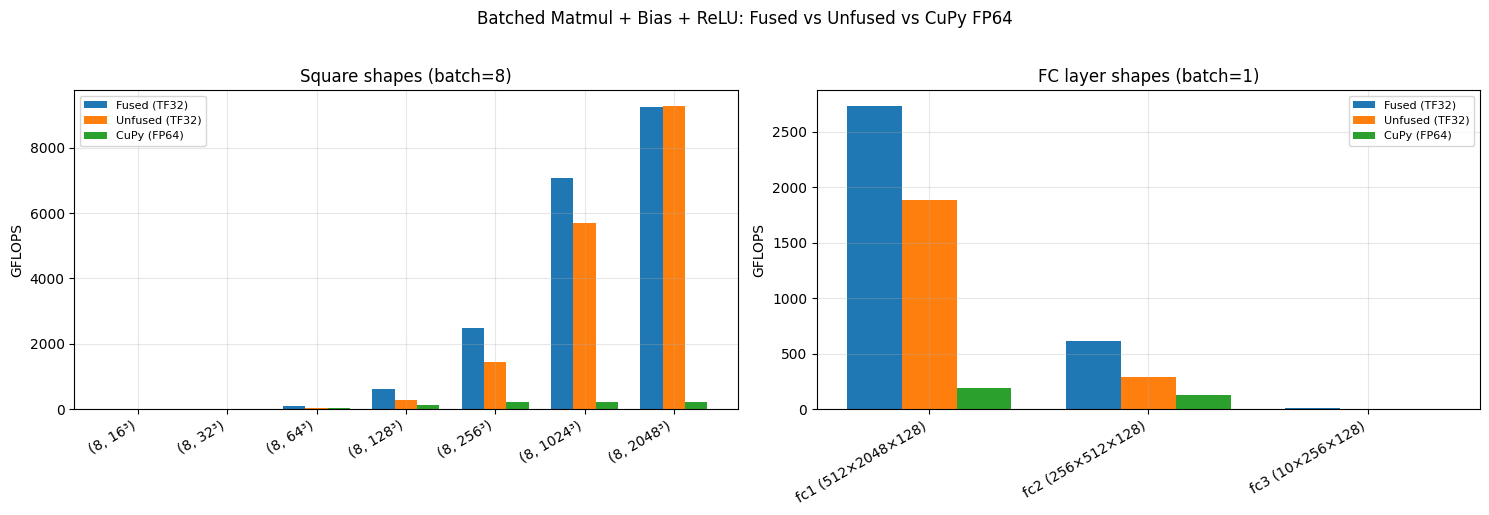

In [20]:
# [v5] Batched matrix multiply — unified three-way benchmark
#
# All shapes are tested against all three implementations so results are
# directly comparable:
#
#   fused    — batched_matmul_bias_relu  (cuBLAS-lt TF32, bias+relu in GEMM registers)
#   unfused  — batched_matmul + cp.maximum(C + bias, 0)  (cuBLAS TF32 + separate CuPy kernel)
#   cupy     — cp.maximum(cp.matmul(A, B) + bias, 0)     (cuBLAS FP64, reference baseline)
#
# A bias vector is added to all shapes so all three paths compute the same operation.
# Square shapes use batch=8; FC shapes use batch=1.

import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt
from rust_matrix_ops import RustMatrixOps

ops = RustMatrixOps()

REPEAT = 10
WARMUP = 3

def _min_time_ms(fn, *args):
    for _ in range(WARMUP):
        fn(*args); cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(REPEAT):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        result = fn(*args)
        cp.cuda.Stream.null.synchronize()
        times.append((time.perf_counter() - t0) * 1e3)
    return result, min(times)

# (label, batch, m, k, n)
shapes = [
    ("(8, 16³)",            8,   16,   16,   16),
    ("(8, 32³)",            8,   32,   32,   32),
    ("(8, 64³)",            8,   64,   64,   64),
    ("(8, 128³)",           8,  128,  128,  128),
    ("(8, 256³)",           8,  256,  256,  256),
    ("(8, 1024³)",          8, 1024, 1024, 1024),
    ("(8, 2048³)",          8, 2048, 2048, 2048),
    ("fc1 (512×2048×128)",  1,  512, 2048,  128),
    ("fc2 (256×512×128)",   1,  256,  512,  128),
    ("fc3 (10×256×128)",    1,   10,  256,  128),
]

print("Warming up GPU...")
_ = cp.matmul(cp.random.random((512,512), dtype=cp.float64),
              cp.random.random((512,512), dtype=cp.float64))
cp.cuda.Stream.null.synchronize()

print()
hdr = f"{'Shape':<26} {'Fused':>9} {'Unfused':>9} {'CuPy':>9}  {'F/U':>6} {'F/C':>6}  {'Max err':>9}"
print(hdr)
print("-" * len(hdr))

rows = []
for label, batch, m, k, n in shapes:
    rng = cp.random.default_rng(0)
    A    = cp.ascontiguousarray(rng.standard_normal((batch, m, k), dtype=cp.float64)) / (np.sqrt(k) * 1.1)
    B    = cp.ascontiguousarray(rng.standard_normal((batch, k, n), dtype=cp.float64)) / (np.sqrt(k) * 1.1)
    bias = rng.standard_normal(m, dtype=cp.float64)

    def fused(A, B, bias):
        return ops.batched_matmul_bias_relu(A, B, bias)

    def unfused(A, B, bias):
        C = ops.batched_matmul(A, B)
        return cp.maximum(C + bias[:, None], 0.0)

    def cupy_ref(A, B, bias):
        return cp.maximum(cp.matmul(A, B) + bias[:, None], 0.0)

    res_f, t_f = _min_time_ms(fused,    A, B, bias)
    res_u, t_u = _min_time_ms(unfused,  A, B, bias)
    res_c, t_c = _min_time_ms(cupy_ref, A, B, bias)

    flops     = 2 * batch * m * k * n
    gf_f      = flops / (t_f * 1e6)
    gf_u      = flops / (t_u * 1e6)
    gf_c      = flops / (t_c * 1e6)
    ratio_fu  = t_u / t_f
    ratio_fc  = t_c / t_f
    max_err   = float(cp.max(cp.abs(res_f[0] - res_c[0])))

    print(f"{label:<26} {gf_f:>7.1f}G {gf_u:>7.1f}G {gf_c:>7.1f}G  "
          f"{ratio_fu:>5.2f}x {ratio_fc:>5.2f}x  {max_err:>9.2e}")

    rows.append(dict(label=label, batch=batch, m=m, k=k, n=n,
                     gf_f=gf_f, gf_u=gf_u, gf_c=gf_c,
                     t_f=t_f, t_u=t_u, t_c=t_c,
                     ratio_fu=ratio_fu, ratio_fc=ratio_fc, max_err=max_err))

    del A, B, bias, res_f, res_u, res_c
    cp.get_default_memory_pool().free_all_blocks()

print()
print("Columns: Fused = batched_matmul_bias_relu (TF32), Unfused = batched_matmul + CuPy bias+relu (TF32),")
print("         CuPy  = cp.matmul + bias + relu (FP64).  F/U = fused speedup vs unfused. F/C = vs CuPy.")
print("Max err: fused vs CuPy FP64 — driven by TF32 GEMM rounding, not by fusion itself.")

# ── Split chart: square shapes (left) vs FC shapes (right) ──────────────────
# Different scales; FC shapes would be invisible on the same axis as (8, 2048³).
square_rows = [r for r in rows if r['batch'] == 8]
fc_rows     = [r for r in rows if r['batch'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, group, title in [
    (axes[0], square_rows, "Square shapes (batch=8)"),
    (axes[1], fc_rows,     "FC layer shapes (batch=1)"),
]:
    labels = [r['label'] for r in group]
    x = np.arange(len(labels))
    w = 0.25
    ax.bar(x - w, [r['gf_f'] for r in group], w, label='Fused (TF32)')
    ax.bar(x,     [r['gf_u'] for r in group], w, label='Unfused (TF32)')
    ax.bar(x + w, [r['gf_c'] for r in group], w, label='CuPy (FP64)')
    ax.set_ylabel('GFLOPS')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Batched Matmul + Bias + ReLU: Fused vs Unfused vs CuPy FP64', y=1.02)
plt.tight_layout()
plt.show()

# Retain variables for summary cell
batched_matmul_results = [
    dict(shape=(r['batch'], r['m'], r['k'], r['n']),
         tensor_gflops=r['gf_f'], reference_gflops=r['gf_c'],
         speedup=r['ratio_fc'], max_diff=r['max_err'], mean_diff=r['max_err'],
         tensor_times=[r['t_f']], reference_times=[r['t_c']])
    for r in rows if r['batch'] == 8
]
batched_matmul_fused_results = [
    dict(shape=(r['batch'], r['m'], r['k'], r['n']),
         tensor_gflops=r['gf_f'], reference_gflops=r['gf_c'],
         speedup=r['ratio_fc'], max_diff=r['max_err'], mean_diff=r['max_err'],
         tensor_times=[r['t_f']], reference_times=[r['t_c']])
    for r in rows if r['batch'] == 1
]


In [21]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


9002

In [22]:
from tensor_matrix_ops import TensorMatrixOps
ops = TensorMatrixOps()

# Quick test
import numpy as np
a = np.random.randn(2, 64, 64)
b = np.random.randn(2, 64, 64)
ref = np.matmul(a, b)

print("Testing FP64 version:")
result = ops.batched_matmul_fp64(a, b)
print(f"Error: {np.max(np.abs(result - ref)):.2e}")


Initializing CUDA...
CUDA initialization complete
Function signatures configured
Testing FP64 version:
Error: 0.00e+00


In [23]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


272

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

In [24]:
from rust_matrix_ops import RustMatrixOps
ops = RustMatrixOps()

# Quick test
import numpy as np
a = np.random.randn(2, 64, 64)
b = np.random.randn(2, 64, 64)
ref = np.matmul(a, b)

print("Testing FP64 version:")
result = ops.batched_matmul_fp64(a, b)
print(f"Error: {np.max(np.abs(result - ref)):.2e}")


Testing FP64 version:
Error: 0.00e+00


In [25]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

In [26]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

batch_size = 8
n = 512

# Use C-order (default), not Fortran order
a = cp.random.random((batch_size, n, n), dtype=cp.float64)
b = cp.random.random((batch_size, n, n), dtype=cp.float64)
a /= (cp.sqrt(n) * 1.1)
b /= (cp.sqrt(n) * 1.1)

# Reference
ref = cp.matmul(a, b)

# FP64 version
result = ops.batched_matmul_fp64(a, b)

# Check error
error = cp.max(cp.abs(result - ref))
print(f"Error with C-order: {float(error):.2e}")



Initializing CUDA...
CUDA initialization complete
Function signatures configured
Error with C-order: 0.00e+00


In [27]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


272

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

In [28]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps

ops = RustMatrixOps()

batch_size = 8
n = 512

# Use C-order (default), not Fortran order
a = cp.random.random((batch_size, n, n), dtype=cp.float64)
b = cp.random.random((batch_size, n, n), dtype=cp.float64)
a /= (cp.sqrt(n) * 1.1)
b /= (cp.sqrt(n) * 1.1)

# Reference
ref = cp.matmul(a, b)

# FP64 version
result = ops.batched_matmul_fp64(a, b)

# Check error
error = cp.max(cp.abs(result - ref))
print(f"Error with C-order: {float(error):.2e}")



Error with C-order: 0.00e+00


In [29]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Batched Matrix Multiplication (FP64)...
Warming up GPU...

Shape: (8, 16, 16, 16)

Shape: (8, 32, 32, 32)

Shape: (8, 64, 64, 64)

Shape: (8, 128, 128, 128)

Shape: (8, 256, 256, 256)

Shape: (8, 1024, 1024, 1024)

Shape: (8, 2048, 2048, 2048)

Results for Batched Matrix Multiplication (FP64)

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(8, 16, 16, 16)                      0.92            0.60         1.54     0.00e+00     0.00e+00
(8, 32, 32, 32)                      6.84            4.57         1.50     0.00e+00     0.00e+00
(8, 64, 64, 64)                     42.24           31.41         1.34     0.00e+00     0.00e+00
(8, 128, 128, 128)                 

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


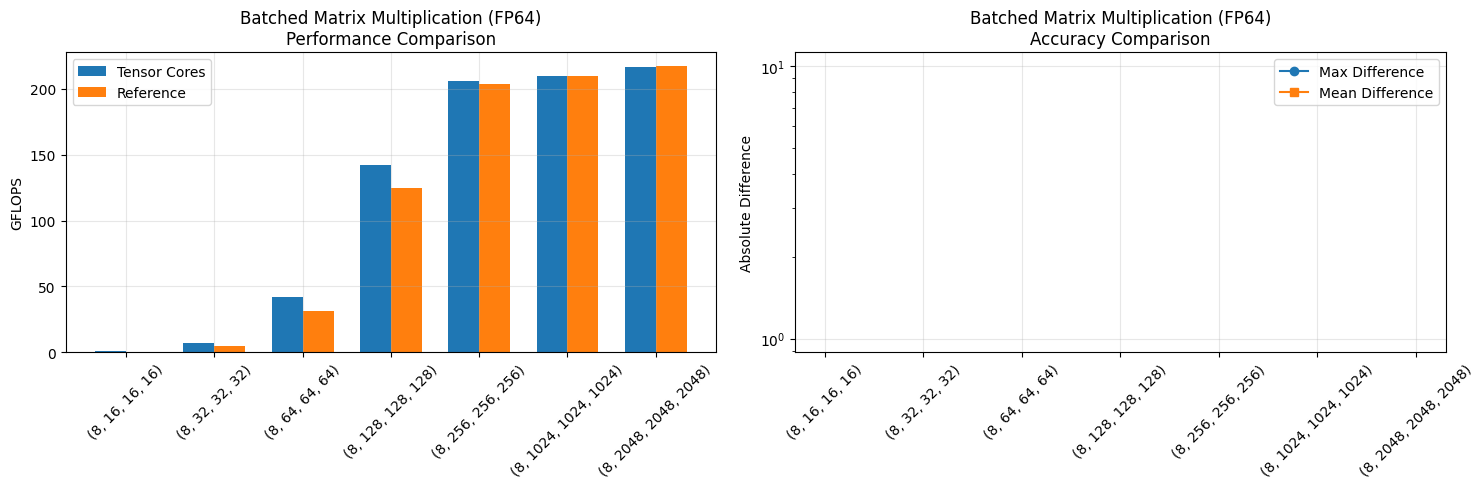

In [30]:
def test_batched_matmul_fp64():
    """Benchmark FP64 batched matrix multiplication (high accuracy version)."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Batched Matrix Multiplication (FP64)"
    
    # Shapes to test (batch_size, m, k, n)
    shapes = [
        (8, 16, 16, 16),
        (8, 32, 32, 32),
        (8, 64, 64, 64),
        (8, 128, 128, 128),
        (8, 256, 256, 256),
        (8, 1024, 1024, 1024),
        (8, 2048, 2048, 2048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random batched matrices for matrix multiplication."""
        batch_size, m, k, n = shape
        
        # Create inputs in the format expected by tensor_ops.batched_matmul_fp64
        a = cp.asfortranarray(cp.random.random((batch_size, m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((batch_size, k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        return [a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for batched matrix multiplication."""
        batch_size, m, k, n = shape
        # Batched matrix multiplication requires 2*batch_size*M*N*K FLOPS
        return 2 * batch_size * m * n * k
    
    # Define tensor operation
    def tensor_op(a, b):
        return tensor_ops.batched_matmul_fp64(a, b)
    
    # Define reference operation (using cupy's batch matmul)
    def reference_op(a, b):
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

batched_matmul_fp64_results = test_batched_matmul_fp64()
cleanup()

In [31]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Batched Matrix Multiplication (FP64) [Rust]...
Warming up GPU...

Shape: (8, 16, 16, 16)

Shape: (8, 32, 32, 32)

Shape: (8, 64, 64, 64)

Shape: (8, 128, 128, 128)

Shape: (8, 256, 256, 256)

Shape: (8, 1024, 1024, 1024)

Shape: (8, 2048, 2048, 2048)

Results for Batched Matrix Multiplication (FP64) [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(8, 16, 16, 16)                      0.90            0.58         1.55     0.00e+00     0.00e+00
(8, 32, 32, 32)                      6.56            4.66         1.41     0.00e+00     0.00e+00
(8, 64, 64, 64)                     41.87           30.92         1.35     0.00e+00     0.00e+00
(8, 128, 128, 128)                 137.06          123.03         1.11     0.00e+00     0.00e+00
(8, 2

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


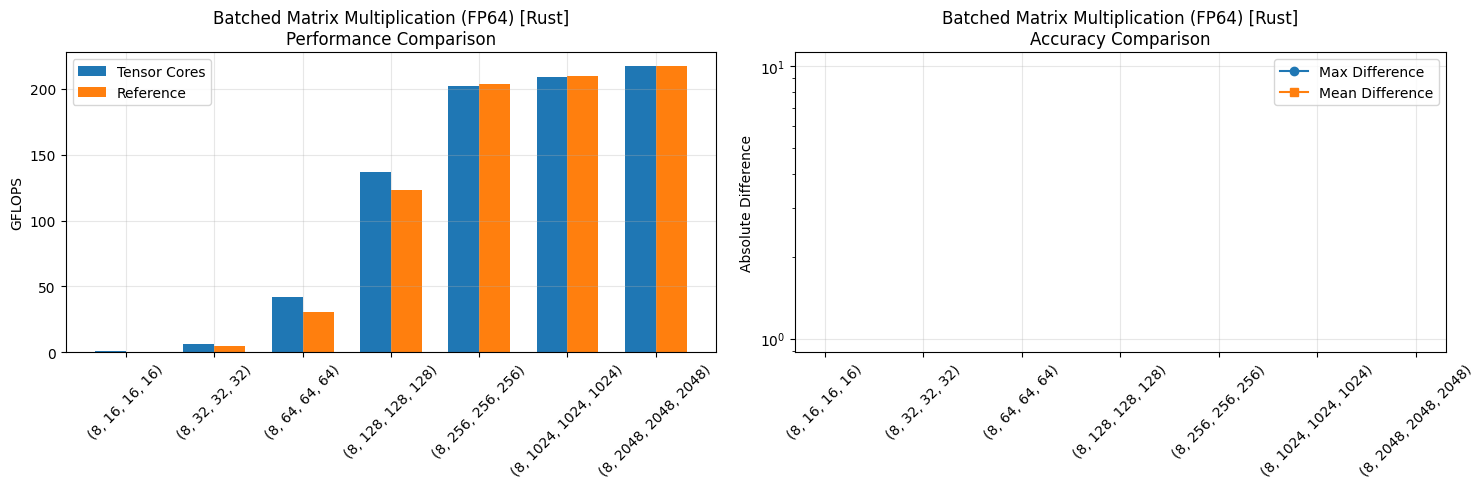

In [32]:
def test_batched_matmul_fp64():
    """Benchmark FP64 batched matrix multiplication (high accuracy version)."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Batched Matrix Multiplication (FP64) [Rust]"
    
    # Shapes to test (batch_size, m, k, n)
    shapes = [
        (8, 16, 16, 16),
        (8, 32, 32, 32),
        (8, 64, 64, 64),
        (8, 128, 128, 128),
        (8, 256, 256, 256),
        (8, 1024, 1024, 1024),
        (8, 2048, 2048, 2048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random batched matrices for matrix multiplication."""
        batch_size, m, k, n = shape
        
        # Create inputs in the format expected by tensor_ops.batched_matmul_fp64
        a = cp.asfortranarray(cp.random.random((batch_size, m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((batch_size, k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        return [a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for batched matrix multiplication."""
        batch_size, m, k, n = shape
        # Batched matrix multiplication requires 2*batch_size*M*N*K FLOPS
        return 2 * batch_size * m * n * k
    
    # Define tensor operation
    def tensor_op(a, b):
        return tensor_ops.batched_matmul_fp64(a, b)
    
    # Define reference operation (using cupy's batch matmul)
    def reference_op(a, b):
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

batched_matmul_fp64_results_rust = test_batched_matmul_fp64()
cleanup()

In [33]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Vector-Matrix Multiplication...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Vector-Matrix Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.80     0.00e+00     0.00e+00
32                                   0.09            0.03         3.27     0.00e+00     0.00e+00
64                                   0.38            0.11         3.57     0.00e+00     0.00e+00
128                                  1.46            0.43         3.44     0.00e+00     0.00e+00
256                                  5.15     

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


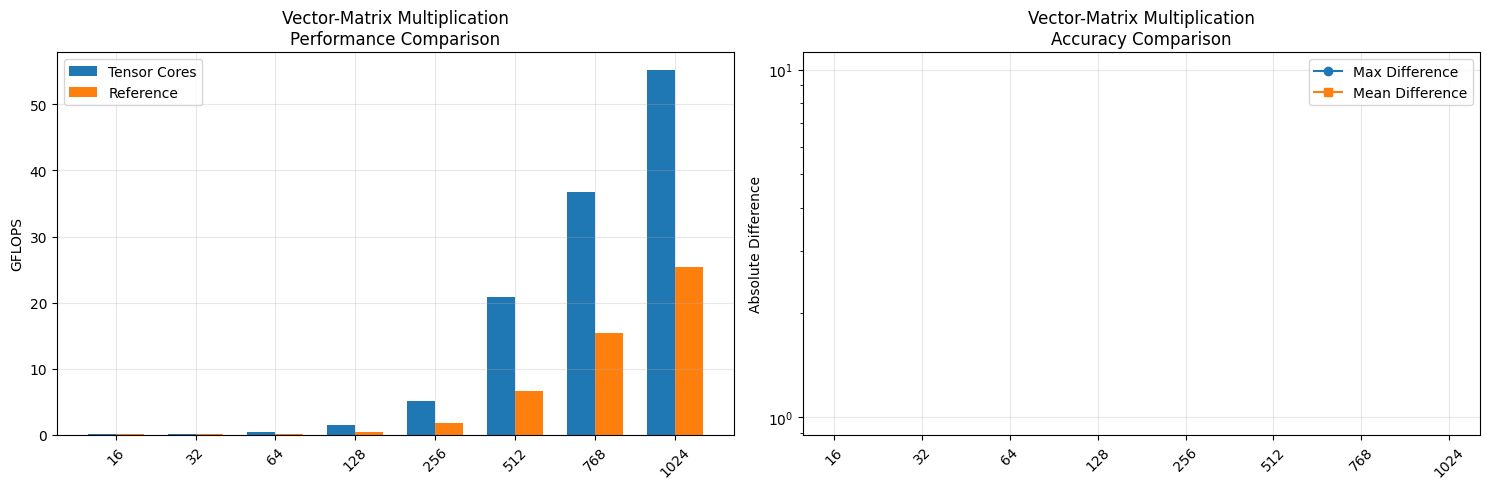

In [34]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_vector_matrix():
    """Benchmark vector-matrix multiplication (v*A) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Vector-Matrix Multiplication"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random vector and matrix in Fortran order."""
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for vector-matrix multiplication."""
        n = size
        # Vector-matrix multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Vector-matrix multiplication is v @ A
        return cp.matmul(v, a)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

vector_matrix_results = test_vector_matrix()
cleanup()

In [35]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Vector-Matrix Multiplication [Rust]...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Vector-Matrix Multiplication [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.58     0.00e+00     0.00e+00
32                                   0.08            0.03         3.05     0.00e+00     0.00e+00
64                                   0.34            0.11         3.15     0.00e+00     0.00e+00
128                                  1.24            0.43         2.86     0.00e+00     0.00e+00
256                                  4.87            1.75         2.78     0.00e+00     0.00e+00
512             

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


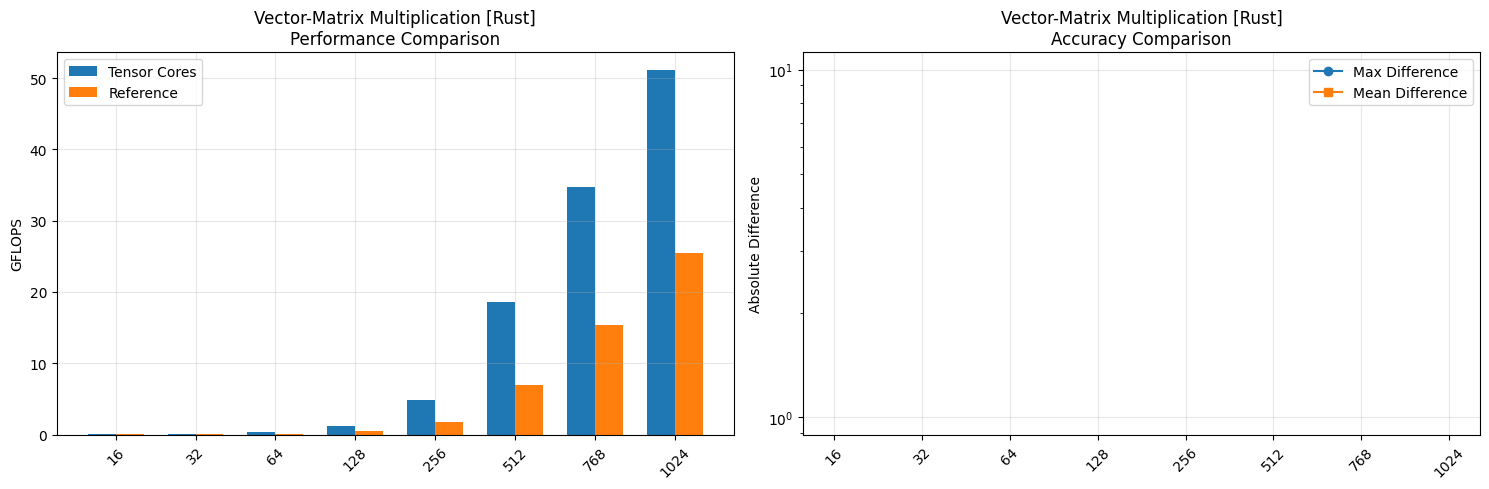

In [36]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps

def test_vector_matrix():
    """Benchmark vector-matrix multiplication (v*A) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Vector-Matrix Multiplication [Rust]"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random vector and matrix in Fortran order."""
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for vector-matrix multiplication."""
        n = size
        # Vector-matrix multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Vector-matrix multiplication is v @ A
        return cp.matmul(v, a)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

vector_matrix_results_rust = test_vector_matrix()
cleanup()

In [37]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Vector-Matrix Optimised Multiplication...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Vector-Matrix Optimised Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.77     0.00e+00     0.00e+00
32                                   0.09            0.03         3.34     0.00e+00     0.00e+00
64                                   0.39            0.11         3.58     0.00e+00     0.00e+00
128                                  1.56            0.41         3.77     0.00e+00     0.00e+00
256                       

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


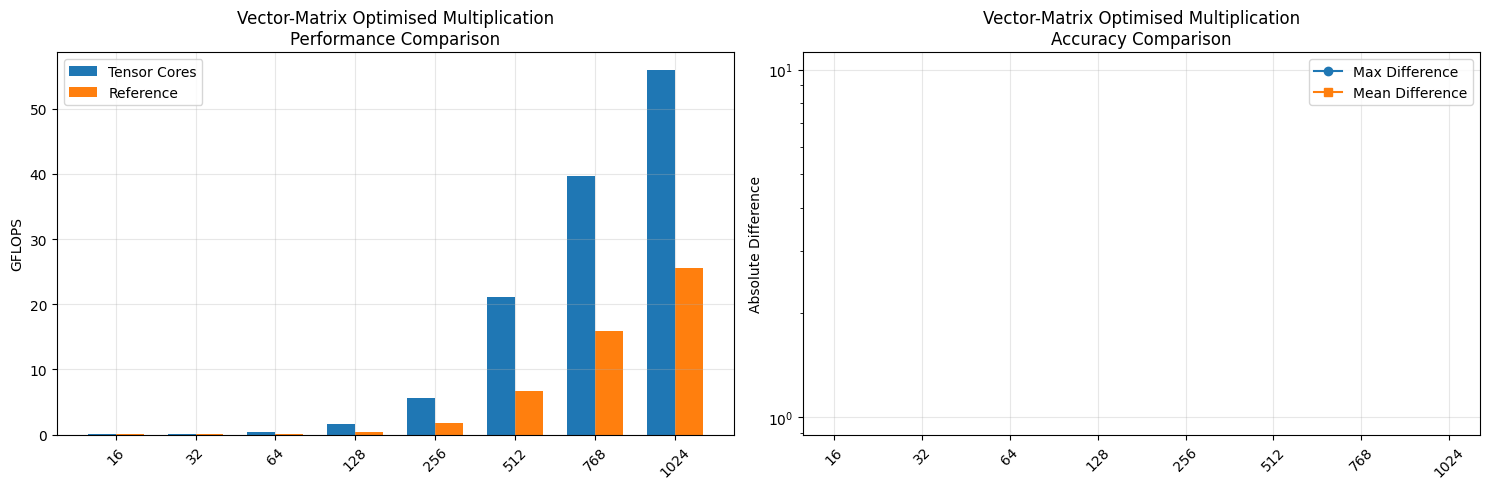

In [38]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_vector_matrix_optimised():
    """Benchmark optimised vector-matrix multiplication (v*A) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Vector-Matrix Optimised Multiplication"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random vector and matrix in Fortran order."""
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for vector-matrix multiplication."""
        n = size
        # Vector-matrix multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Vector-matrix multiplication is v @ A
        return cp.matmul(v, a)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

vector_matrix_optimised_results = test_vector_matrix_optimised()
cleanup()

In [39]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Vector-Matrix Optimised Multiplication [Rust]...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Vector-Matrix Optimised Multiplication [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.42     0.00e+00     0.00e+00
32                                   0.08            0.03         3.03     0.00e+00     0.00e+00
64                                   0.33            0.11         3.01     0.00e+00     0.00e+00
128                                  1.32            0.44         3.02     0.00e+00     0.00e+00
256                                  4.78            1.76         2.71     0.00e+00     0.00e

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


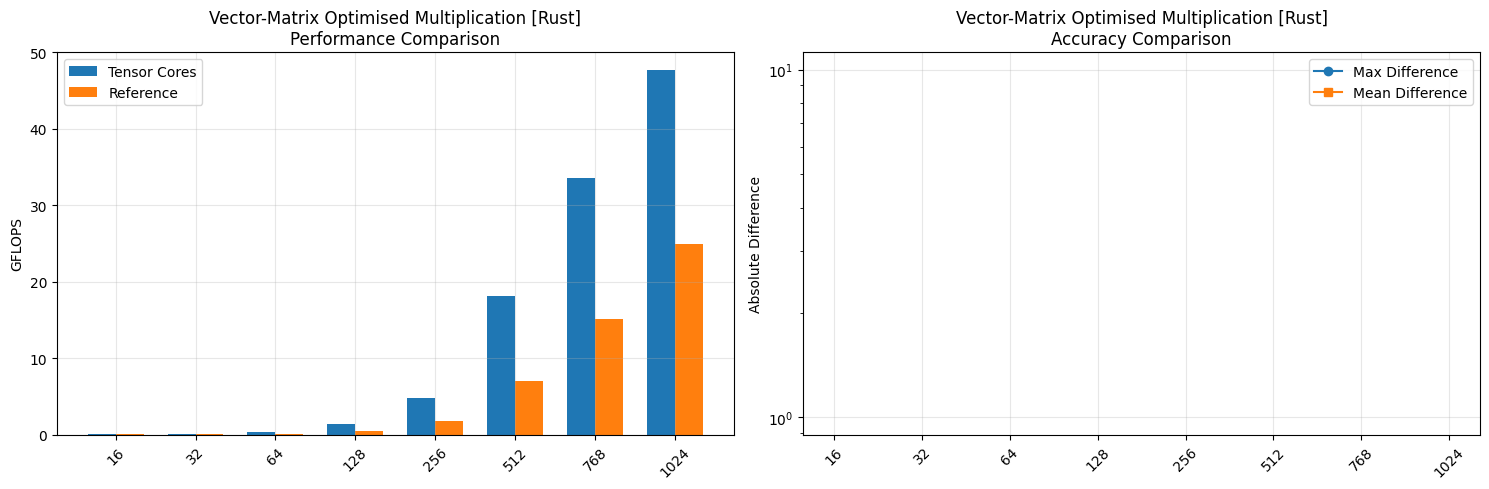

In [40]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps

def test_vector_matrix_optimised():
    """Benchmark optimised vector-matrix multiplication (v*A) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Vector-Matrix Optimised Multiplication [Rust]"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random vector and matrix in Fortran order."""
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for vector-matrix multiplication."""
        n = size
        # Vector-matrix multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Vector-matrix multiplication is v @ A
        return cp.matmul(v, a)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

vector_matrix_optimised_results_rust = test_vector_matrix_optimised()
cleanup()

In [41]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Matrix-Vector Multiplication...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Matrix-Vector Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.84     0.00e+00     0.00e+00
32                                   0.09            0.03         3.67     0.00e+00     0.00e+00
64                                   0.38            0.11         3.52     0.00e+00     0.00e+00
128                                  1.43            0.41         3.48     0.00e+00     0.00e+00
256                                  5.80     

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


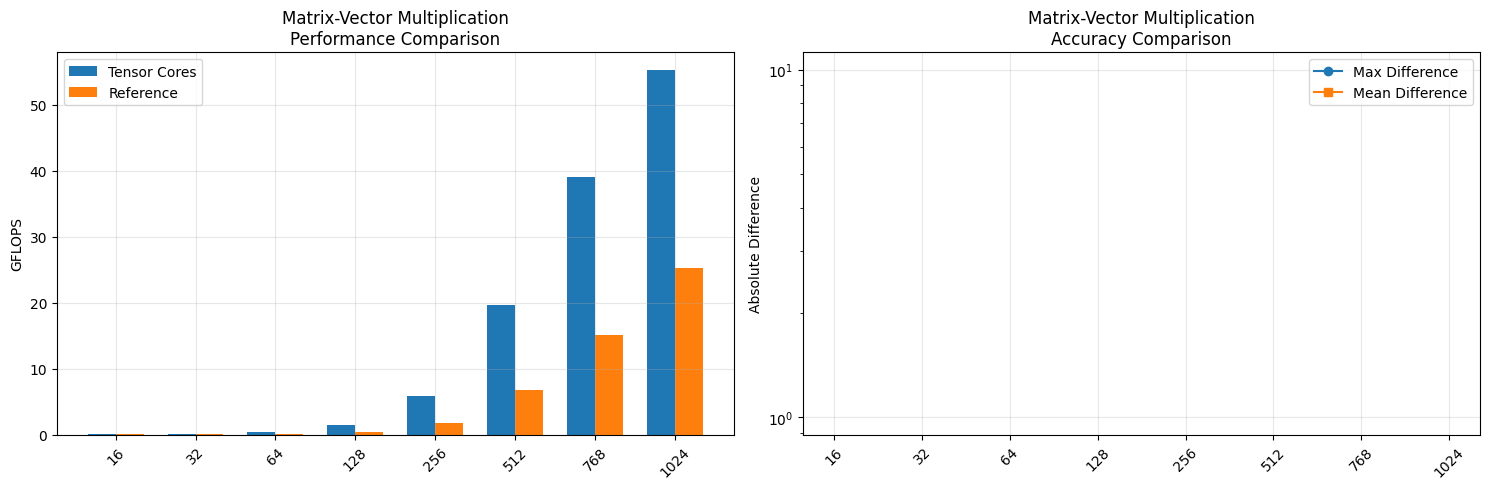

In [42]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_matrix_vector():
    """Benchmark matrix-vector multiplication (A*v) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Matrix-Vector Multiplication"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random matrix and vector in Fortran order."""
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(size) * 1.1)
        v /= (cp.sqrt(size) * 1.1)
        
        return [a, v]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for matrix-vector multiplication."""
        n = size
        # Matrix-vector multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(a, v):
        return tensor_ops.matmul_vector(a, v)
    
    # Define reference operation
    def reference_op(a, v):
        # Matrix-vector multiplication is A @ v
        return cp.matmul(a, v)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_vector_results = test_matrix_vector()
cleanup()

In [43]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Matrix-Vector Multiplication [Rust]...
Warming up GPU...

Shape: 16

Shape: 32

Shape: 64

Shape: 128

Shape: 256

Shape: 512

Shape: 768

Shape: 1024

Results for Matrix-Vector Multiplication [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
16                                   0.02            0.01         2.47     0.00e+00     0.00e+00
32                                   0.08            0.03         3.03     0.00e+00     0.00e+00
64                                   0.32            0.11         3.00     0.00e+00     0.00e+00
128                                  1.19            0.44         2.73     0.00e+00     0.00e+00
256                                  5.01            1.71         2.93     0.00e+00     0.00e+00
512             

/tmp/ipykernel_787512/2550936978.py:182: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


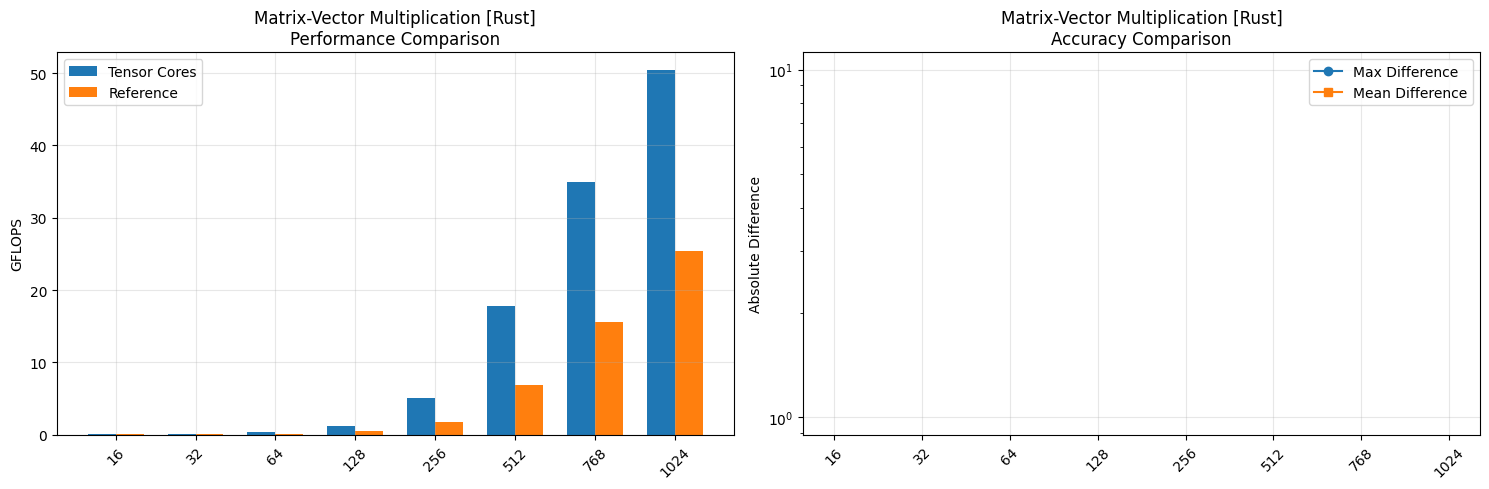

In [44]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps

def test_matrix_vector():
    """Benchmark matrix-vector multiplication (A*v) operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Matrix-Vector Multiplication [Rust]"
    
    # Sizes to test (n for n×n matrices)
    sizes = [16, 32, 64, 128, 256, 512, 768, 1024]
    
    # Create input data function
    def create_inputs(size):
        """Create a random matrix and vector in Fortran order."""
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        v = cp.asfortranarray(cp.random.random(size, dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(size) * 1.1)
        v /= (cp.sqrt(size) * 1.1)
        
        return [a, v]
    
    # Calculate FLOPS
    def calculate_flops(size):
        """Calculate FLOPS for matrix-vector multiplication."""
        n = size
        # Matrix-vector multiplication requires 2*n*n FLOPS
        return 2 * n * n
    
    # Define tensor operation
    def tensor_op(a, v):
        return tensor_ops.matmul_vector(a, v)
    
    # Define reference operation
    def reference_op(a, v):
        # Matrix-vector multiplication is A @ v
        return cp.matmul(a, v)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        sizes,
        create_inputs,
        calculate_flops
    )
    
    return results

matrix_vector_results_rust = test_matrix_vector()
cleanup()

In [45]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Batched Vector Multiplication...
Warming up GPU...

Shape: (16, 10)

Shape: (32, 10)

Shape: (64, 10)

Shape: (128, 8)

Shape: (256, 4)

Shape: (512, 2)

Results for Batched Vector Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 10)                             0.04            0.01         7.83     3.59e-08     7.85e-09
(32, 10)                             0.17            0.02         7.02     2.32e-08     6.30e-09
(64, 10)                             0.72            0.10         7.50     4.45e-08     9.79e-09
(128, 8)                             2.28            0.38         5.95     4.02e-08     8.59e-09
(256, 4)                            

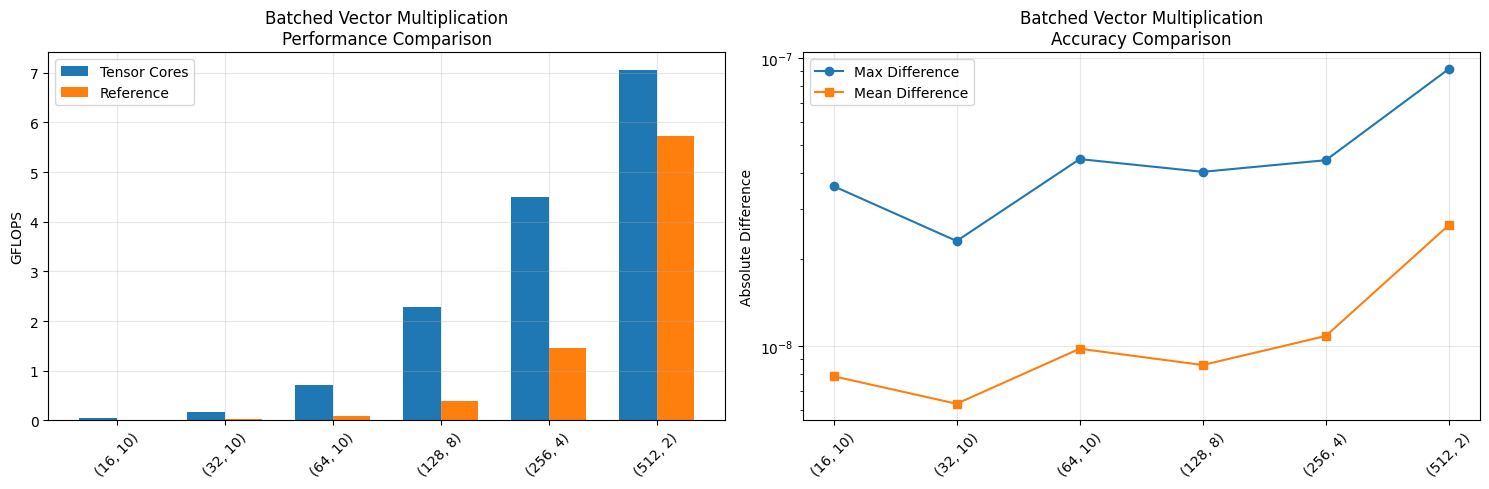

In [46]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_batched_vector():
    """Benchmark batched vector multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Batched Vector Multiplication"
    
    # Shapes to test (size, batch_size)
    shapes = [
        (16, 10),
        (32, 10),
        (64, 10),
        (128, 8),
        (256, 4),
        (512, 2)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random vectors and matrix in Fortran order."""
        size, batch_size = shape
        
        # Create batch of vectors (size, batch_size) in Fortran order
        v = cp.asfortranarray(cp.random.random((size, batch_size), dtype=cp.float64))
        
        # Create matrix (size, size) in Fortran order
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for batched vector multiplication."""
        size, batch_size = shape
        # Batched vector-matrix multiplication requires 2*size*size*batch_size FLOPS
        return 2 * size * size * batch_size
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.batched_vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Manual implementation of batched vector-matrix multiplication
        size, batch_size = v.shape
        result = cp.empty((batch_size, size), dtype=cp.float64)
        
        for i in range(batch_size):
            result[i] = cp.matmul(a, v[:, i])
            
        return result
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

batched_vector_results = test_batched_vector()
cleanup()

In [47]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Batched Vector Multiplication [Rust]...
Warming up GPU...

Shape: (16, 10)

Shape: (32, 10)

Shape: (64, 10)

Shape: (128, 8)

Shape: (256, 4)

Shape: (512, 2)

Results for Batched Vector Multiplication [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(16, 10)                             0.06            0.01        11.27     4.32e-05     1.53e-05
(32, 10)                             0.26            0.02        10.77     4.56e-05     1.28e-05
(64, 10)                             1.07            0.09        11.49     2.72e-05     6.44e-06
(128, 8)                             3.25            0.38         8.60     2.00e-05     5.02e-06
(256, 4)                             6.87            1.48         4.64     1.59e-05     4.06e-06
(512, 

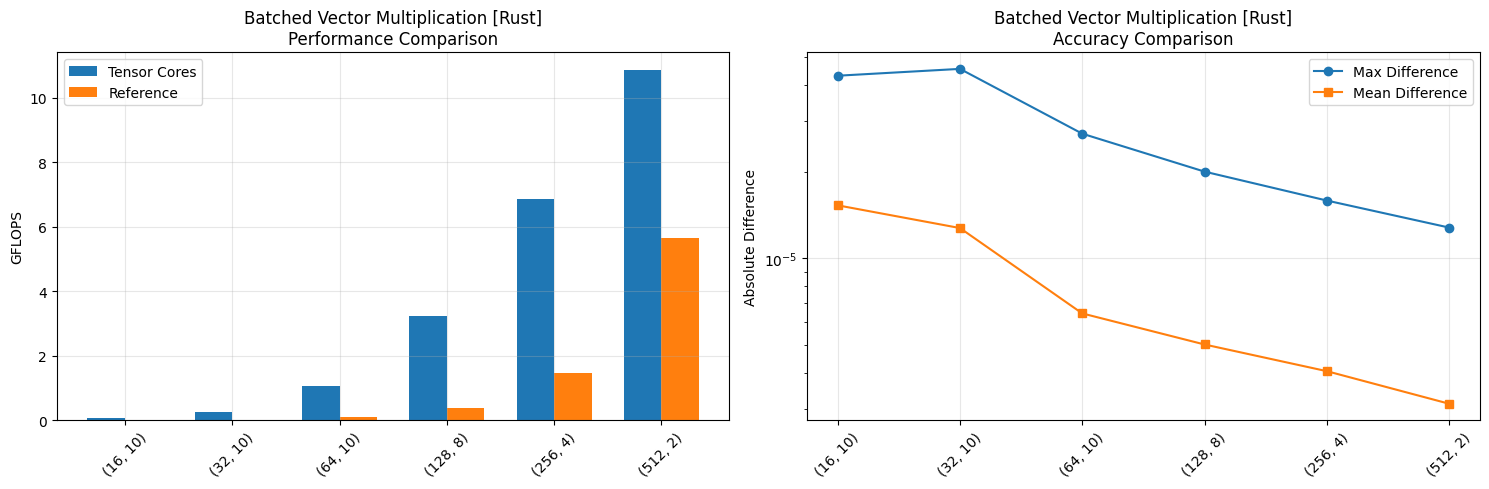

In [48]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps

def test_batched_vector():
    """Benchmark batched vector multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Batched Vector Multiplication [Rust]"
    
    # Shapes to test (size, batch_size)
    shapes = [
        (16, 10),
        (32, 10),
        (64, 10),
        (128, 8),
        (256, 4),
        (512, 2)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random vectors and matrix in Fortran order."""
        size, batch_size = shape
        
        # Create batch of vectors (size, batch_size) in Fortran order
        v = cp.asfortranarray(cp.random.random((size, batch_size), dtype=cp.float64))
        
        # Create matrix (size, size) in Fortran order
        a = cp.asfortranarray(cp.random.random((size, size), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        v /= (cp.sqrt(size) * 1.1)
        a /= (cp.sqrt(size) * 1.1)
        
        return [v, a]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for batched vector multiplication."""
        size, batch_size = shape
        # Batched vector-matrix multiplication requires 2*size*size*batch_size FLOPS
        return 2 * size * size * batch_size
    
    # Define tensor operation
    def tensor_op(v, a):
        return tensor_ops.batched_vector_matmul(v, a)
    
    # Define reference operation
    def reference_op(v, a):
        # Manual implementation of batched vector-matrix multiplication
        size, batch_size = v.shape
        result = cp.empty((batch_size, size), dtype=cp.float64)
        
        for i in range(batch_size):
            result[i] = cp.matmul(a, v[:, i])
            
        return result
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

batched_vector_results_rust = test_batched_vector()
cleanup()

In [49]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Benchmarking Strided Batch Matrix Multiplication...
Warming up GPU...

Shape: (8, 16, 16, 16)

Shape: (8, 32, 32, 32)

Shape: (8, 64, 64, 64)

Shape: (8, 128, 128, 128)

Shape: (8, 256, 256, 256)

Shape: (8, 512, 512, 512)

Shape: (8, 1024, 1024, 1024)

Shape: (8, 2048, 2048, 2048)

Results for Strided Batch Matrix Multiplication

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(8, 16, 16, 16)                      0.94            0.60         1.57     3.72e-08     7.16e-09
(8, 32, 32, 32)                      7.93            4.56         1.74     7.72e-05     1.24e-05
(8, 64, 64, 64)                     56.90           31.63         1.80     4.15e-05     7.61e-06
(8, 128, 1

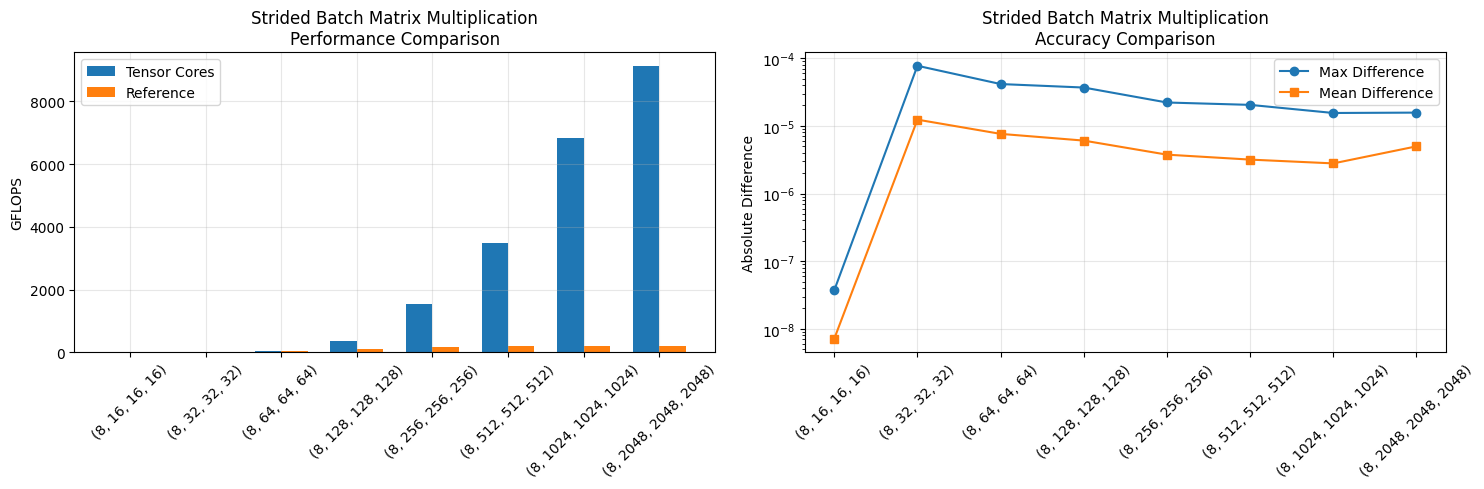

In [50]:
import numpy as np
import cupy as cp
from tensor_matrix_ops import TensorMatrixOps

def test_strided_batch():
    """Benchmark strided batch matrix multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = TensorMatrixOps()
    
    # Operation name
    operation_name = "Strided Batch Matrix Multiplication"
    
    # Shapes to test (batch_size, m, k, n)
    shapes = [
        (8, 16, 16, 16),
        (8, 32, 32, 32),
        (8, 64, 64, 64),
        (8, 128, 128, 128),
        (8, 256, 256, 256),
        (8, 512, 512, 512),
        (8, 1024, 1024, 1024),
        (8, 2048, 2048, 2048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random matrices for strided batch matrix multiplication."""
        batch_size, m, k, n = shape
        
        # Create inputs in the correct format and memory layout
        a = cp.asfortranarray(cp.random.random((batch_size, m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((batch_size, k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        # Prepare extra parameters needed for strided_batch_matmul
        return [m, k, n, batch_size, a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for strided batch matrix multiplication."""
        batch_size, m, k, n = shape
        # Strided batch matrix multiplication requires 2*batch_size*m*n*k FLOPS
        return 2 * batch_size * m * n * k
    
    # Define tensor operation
    def tensor_op(m, k, n, batch_size, a, b):
        return tensor_ops.strided_batch_matmul(m, k, n, batch_size, a, b)
    
    # Define reference operation
    def reference_op(m, k, n, batch_size, a, b):
        # Standard batch matmul for comparison
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

strided_batch_results = test_strided_batch()
cleanup()

In [51]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Benchmarking Strided Batch Matrix Multiplication [Rust]...
Warming up GPU...

Shape: (8, 16, 16, 16)

Shape: (8, 32, 32, 32)

Shape: (8, 64, 64, 64)

Shape: (8, 128, 128, 128)

Shape: (8, 256, 256, 256)

Shape: (8, 512, 512, 512)

Shape: (8, 1024, 1024, 1024)

Shape: (8, 2048, 2048, 2048)

Results for Strided Batch Matrix Multiplication [Rust]

Performance Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS Reference GFLOPS      Speedup     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(8, 16, 16, 16)                      0.76            0.59         1.28     4.34e-08     6.97e-09
(8, 32, 32, 32)                      5.66            4.57         1.24     5.44e-05     1.22e-05
(8, 64, 64, 64)                     47.21           32.33         1.46     4.31e-05     7.68e-06
(8, 128, 128, 128)                 303.79          124.61         2.44     3.

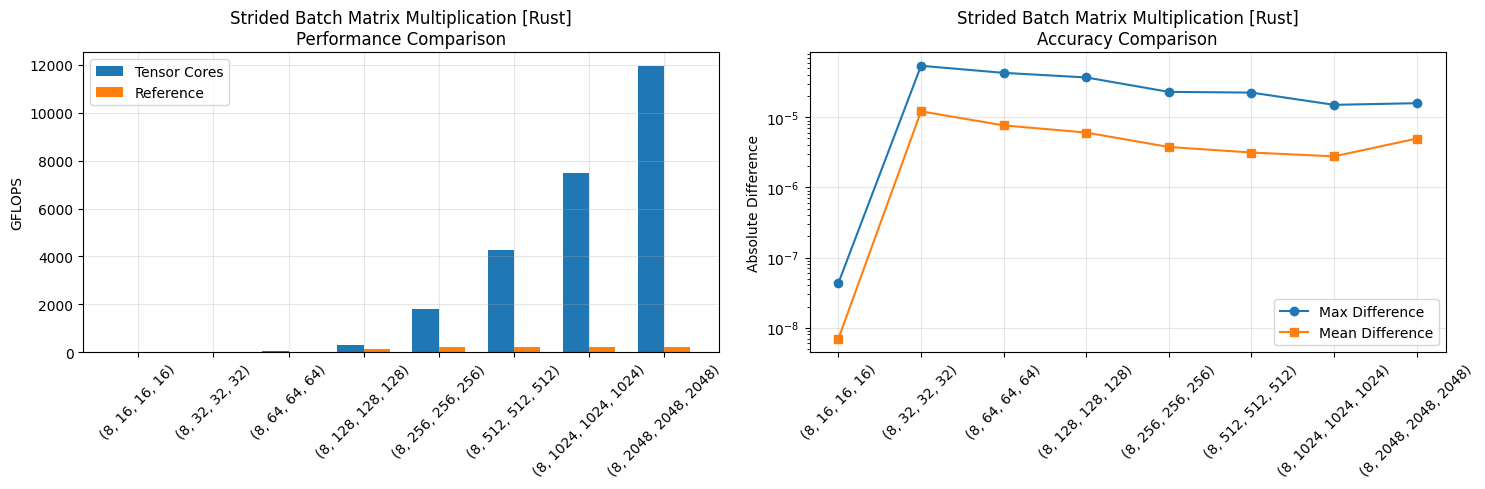

In [52]:
import numpy as np
import cupy as cp
from rust_matrix_ops import RustMatrixOps

def test_strided_batch():
    """Benchmark strided batch matrix multiplication operations."""
    # Initialize TensorMatrixOps
    tensor_ops = RustMatrixOps()
    
    # Operation name
    operation_name = "Strided Batch Matrix Multiplication [Rust]"
    
    # Shapes to test (batch_size, m, k, n)
    shapes = [
        (8, 16, 16, 16),
        (8, 32, 32, 32),
        (8, 64, 64, 64),
        (8, 128, 128, 128),
        (8, 256, 256, 256),
        (8, 512, 512, 512),
        (8, 1024, 1024, 1024),
        (8, 2048, 2048, 2048)
    ]
    
    # Create input data function
    def create_inputs(shape):
        """Create random matrices for strided batch matrix multiplication."""
        batch_size, m, k, n = shape
        
        # Create inputs in the correct format and memory layout
        a = cp.asfortranarray(cp.random.random((batch_size, m, k), dtype=cp.float64))
        b = cp.asfortranarray(cp.random.random((batch_size, k, n), dtype=cp.float64))
        
        # Scale to prevent numerical overflow
        a /= (cp.sqrt(k) * 1.1)
        b /= (cp.sqrt(k) * 1.1)
        
        # Prepare extra parameters needed for strided_batch_matmul
        return [m, k, n, batch_size, a, b]
    
    # Calculate FLOPS
    def calculate_flops(shape):
        """Calculate FLOPS for strided batch matrix multiplication."""
        batch_size, m, k, n = shape
        # Strided batch matrix multiplication requires 2*batch_size*m*n*k FLOPS
        return 2 * batch_size * m * n * k
    
    # Define tensor operation
    def tensor_op(m, k, n, batch_size, a, b):
        return tensor_ops.strided_batch_matmul(m, k, n, batch_size, a, b)
    
    # Define reference operation
    def reference_op(m, k, n, batch_size, a, b):
        # Standard batch matmul for comparison
        return cp.matmul(a, b)
    
    # Run the benchmark
    results = run_benchmark(
        operation_name,
        tensor_op,
        reference_op,
        shapes,
        create_inputs,
        calculate_flops
    )
    
    return results

strided_batch_results_rust = test_strided_batch()
cleanup()

In [53]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


136

In [54]:
def generate_summary_report(all_results):
    sep = "-" * 100
    print("\nSummary of All Benchmarks:")
    print(sep)
    print(f"{'Operation':30} {'Shape':20} {'Tensor GFLOPS':>15} {'Reference GFLOPS':>15} {'Speedup':>10} {'Max Diff':>10}")
    print(sep)
    for operation, results in all_results.items():
        for r in results:
            shape_str = str(r['shape'])
            print(f"{operation:30} {shape_str:20} {r['tensor_gflops']:15.2f} {r['reference_gflops']:15.2f}"
                  f" {r['speedup']:10.2f} {r['max_diff']:10.2e}")

_all = {
    "Matrix Power":                        matrix_power_results,
    "Improved Matmul32 (FP32 acc)":        improved_matmul32_results,
    "Improved Matmul64 (near-FP64)":       improved_matmul64_results,
    "Matrix Multiplication":               matrix_multiply_results,
    "Batched Matrix Multiplication":       batched_matmul_results,
    "Batched Matmul+Bias+ReLU (fused v5)": batched_matmul_fused_results,
    "Vector-Matrix Multiplication":        vector_matrix_results,
    "Matrix-Vector Multiplication":        matrix_vector_results,
    "Batched Vector Multiplication":       batched_vector_results,
    "Strided Batch Matrix Multiplication": strided_batch_results,
}
all_results = {k: v for k, v in _all.items() if v}
generate_summary_report(all_results)



Summary of All Benchmarks:
----------------------------------------------------------------------------------------------------
Operation                      Shape                  Tensor GFLOPS Reference GFLOPS    Speedup   Max Diff
----------------------------------------------------------------------------------------------------
Matrix Power                   (16, 16)                        0.16            0.12       1.33   2.15e-04
Matrix Power                   (32, 32)                        1.31            0.93       1.41   4.96e-04
Matrix Power                   (64, 64)                       11.76            7.18       1.64   4.74e-04
Matrix Power                   (128, 128)                     99.72           52.36       1.90   8.92e-04
Matrix Power                   (256, 256)                    744.31          128.12       5.81   1.32e-03
Matrix Power                   (512, 512)                   3771.67          178.34      21.15   2.05e-03
Matrix Power               

Initializing CUDA...
CUDA initialization complete
Function signatures configured

Testing 4D Tensor Multiplication...

Shape: (2, 2, 16, 16)

Array shapes:
Input a: (2, 2, 16, 16)
Input b: (2, 2, 16, 16)
Output tensor: (2, 2, 16, 16)
Output cupy: (2, 2, 16, 16)

Shape: (4, 4, 32, 32)

Shape: (8, 8, 64, 64)

Shape: (8, 8, 128, 128)

Shape: (8, 8, 256, 256)

Shape: (8, 8, 512, 512)

Shape: (8, 8, 640, 640)

Detailed Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS     CuPy GFLOPS     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(2, 2, 16, 16)                       0.28            0.09     3.42e-08     8.02e-09
(4, 4, 32, 32)                       8.90            0.73     6.56e-05     1.22e-05
(8, 8, 64, 64)                     186.92            6.25     4.40e-05     7.61e-06
(8, 8, 128, 128)                   631.69           49.97     4.00e-05  

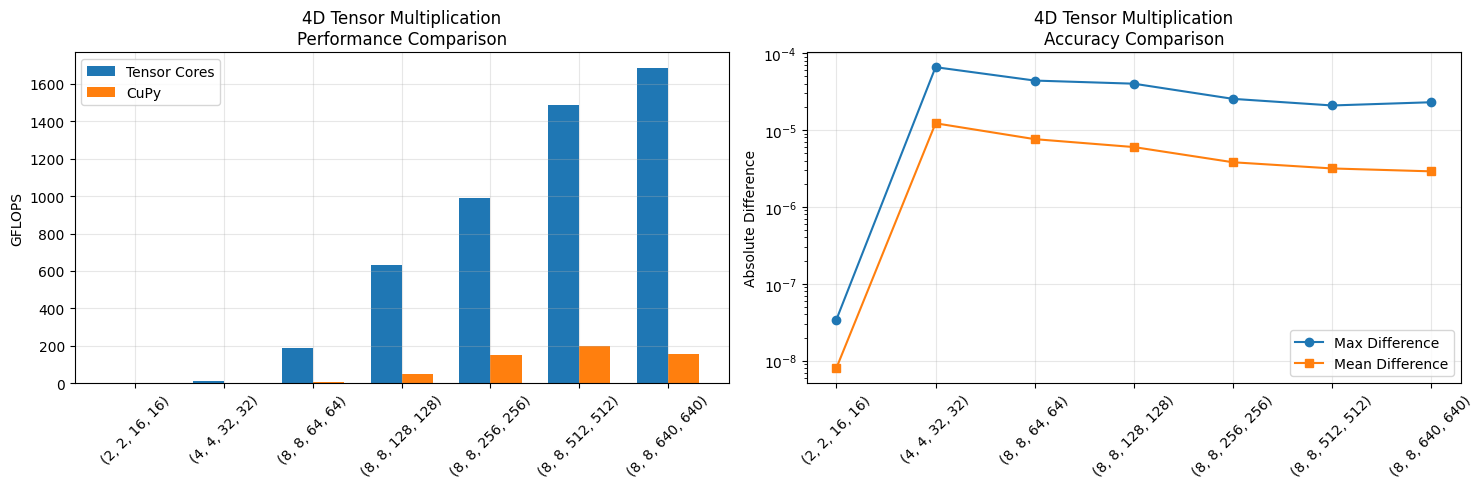

In [55]:
import numpy as np
import cupy as cp
import time
from tensor_matrix_ops import TensorMatrixOps
import matplotlib.pyplot as plt

# Cell for Tensor 4D Test
def test_tensor_4d():
    """Test 4D tensor multiplication with correct input format."""
    operation_name = "4D Tensor Multiplication"
    shapes = [
        (2, 2, 16, 16),     # (batch1, batch2, m, n)
        (4, 4, 32, 32),
        (8, 8, 64, 64),
        (8, 8, 128, 128),
        (8, 8, 256, 256),
        (8, 8, 512, 512),
        (8, 8, 640, 640)
    ]
    tensor_ops = TensorMatrixOps()
    
    print(f"\nTesting {operation_name}...")
    results = []
    
    for shape in shapes:
        print(f"\nShape: {shape}")
        try:
            batch1, batch2, m, n = shape
            
            # Create test data in format expected by tensor_4d_matmul
            a = cp.random.random((batch1, batch2, m, n), dtype=cp.float64)
            b = cp.random.random((batch1, batch2, n, n), dtype=cp.float64)
            
            # Scale inputs
            a /= (cp.sqrt(n) * 1.1)
            b /= (cp.sqrt(n) * 1.1)
            
            # Calculate FLOPS: regular matmul FLOPS * number of matmuls
            flops = 2 * m * n * n * batch1 * batch2
            
            # Time tensor core implementation
            tensor_times = []
            for i in range(3):
                cp.cuda.runtime.deviceSynchronize()
                start = time.perf_counter()
                c_tensor = tensor_ops.tensor_4d_matmul(a, b)
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                tensor_times.append(elapsed)
            
            # Time cupy implementation
            cupy_times = []
            for i in range(3):
                cp.cuda.runtime.deviceSynchronize()
                start = time.perf_counter()
                c_cupy = cp.empty((batch1, batch2, m, n), dtype=cp.float64)
                for i in range(batch1):
                    for j in range(batch2):
                        c_cupy[i,j] = cp.matmul(a[i,j], b[i,j])
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                cupy_times.append(elapsed)
            
            # Print shapes for verification
            if shape == shapes[0]:  # Only for first shape
                print("\nArray shapes:")
                print(f"Input a: {a.shape}")
                print(f"Input b: {b.shape}")
                print(f"Output tensor: {c_tensor.shape}")
                print(f"Output cupy: {c_cupy.shape}")
            
            # Compare results
            max_diff = cp.max(cp.abs(c_tensor - c_cupy))
            mean_diff = cp.mean(cp.abs(c_tensor - c_cupy))
            
            results.append({
                'shape': shape,
                'flops': flops,
                'tensor_times': tensor_times,
                'cupy_times': cupy_times,
                'tensor_gflops': flops / (min(tensor_times) * 1e9),
                'cupy_gflops': flops / (min(cupy_times) * 1e9),
                'max_diff': float(max_diff),
                'mean_diff': float(mean_diff),
                'sample_tensor': cp.asnumpy(c_tensor[0,0,:5,:5]),  # First batch, first 5x5 elements
                'sample_cupy': cp.asnumpy(c_cupy[0,0,:5,:5])      # First batch, first 5x5 elements
            })
            
            # Cleanup
            del a, b, c_tensor, c_cupy
            cp.cuda.runtime.deviceSynchronize()
            cp.get_default_memory_pool().free_all_blocks()
            
        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()
            
    if results:
        print("\nDetailed Comparison:")
        print("-" * 80)
        print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'CuPy GFLOPS':>15} {'Max Diff':>12} {'Mean Diff':>12}")
        print("-" * 80)
        
        for r in results:
            shape_str = str(r['shape'])
            print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['cupy_gflops']:15.2f} "
                  f"{r['max_diff']:12.2e} {r['mean_diff']:12.2e}")
        
        print("\nSample Output Comparison (first 5x5 slice):")
        print("-" * 80)
        for r in results:
            print(f"\nShape: {r['shape']}")
            print(f"Tensor:\n{r['sample_tensor']}")
            print(f"CuPy:\n{r['sample_cupy']}")
        
        # Create plots with operation name
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Performance comparison
        x = np.arange(len(results))
        width = 0.35
        
        tensor_gflops = [r['tensor_gflops'] for r in results]
        cupy_gflops = [r['cupy_gflops'] for r in results]
        
        ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
        ax1.bar(x + width/2, cupy_gflops, width, label='CuPy')
        ax1.set_ylabel('GFLOPS')
        ax1.set_title(f'{operation_name}\nPerformance Comparison')
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(r['shape']) for r in results], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Accuracy comparison
        max_diffs = [r['max_diff'] for r in results]
        mean_diffs = [r['mean_diff'] for r in results]
        
        ax2.plot(x, max_diffs, 'o-', label='Max Difference')
        ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
        ax2.set_ylabel('Absolute Difference')
        ax2.set_title(f'{operation_name}\nAccuracy Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(r['shape']) for r in results], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale('log')
        
        plt.tight_layout()
        plt.show()
    
    return results

# Run test
results = test_tensor_4d()

In [56]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


23433

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):


Testing 4D Tensor Multiplication [Rust]...

Shape: (2, 2, 16, 16)

Array shapes:
Input a: (2, 2, 16, 16)
Input b: (2, 2, 16, 16)
Output tensor: (2, 2, 16, 16)
Output cupy: (2, 2, 16, 16)

Shape: (4, 4, 32, 32)

Shape: (8, 8, 64, 64)

Shape: (8, 8, 128, 128)

Shape: (8, 8, 256, 256)

Shape: (8, 8, 512, 512)

Shape: (8, 8, 640, 640)

Detailed Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS     CuPy GFLOPS     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(2, 2, 16, 16)                       0.34            0.09     3.44e-08     6.82e-09
(4, 4, 32, 32)                      15.35            0.76     7.90e-05     1.19e-05
(8, 8, 64, 64)                     387.90            6.18     4.58e-05     7.51e-06
(8, 8, 128, 128)                  1232.97           49.70     4.02e-05     6.04e-06
(8, 8, 256, 256)                  2518.16          149.88     

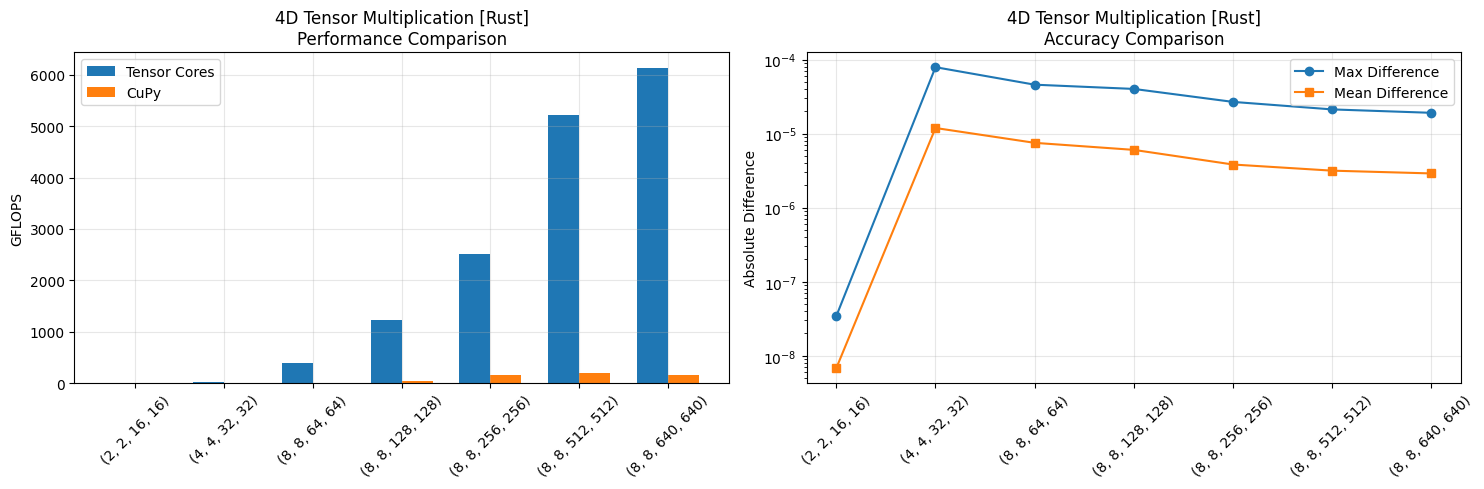

In [57]:
import numpy as np
import cupy as cp
import time
from rust_matrix_ops import RustMatrixOps
import matplotlib.pyplot as plt

# Cell for Tensor 4D Test
def test_tensor_4d():
    """Test 4D tensor multiplication with correct input format."""
    operation_name = "4D Tensor Multiplication [Rust]"
    shapes = [
        (2, 2, 16, 16),     # (batch1, batch2, m, n)
        (4, 4, 32, 32),
        (8, 8, 64, 64),
        (8, 8, 128, 128),
        (8, 8, 256, 256),
        (8, 8, 512, 512),
        (8, 8, 640, 640)
    ]
    tensor_ops = RustMatrixOps()
    
    print(f"\nTesting {operation_name}...")
    results = []
    
    for shape in shapes:
        print(f"\nShape: {shape}")
        try:
            batch1, batch2, m, n = shape
            
            # Create test data in format expected by tensor_4d_matmul
            a = cp.random.random((batch1, batch2, m, n), dtype=cp.float64)
            b = cp.random.random((batch1, batch2, n, n), dtype=cp.float64)
            
            # Scale inputs
            a /= (cp.sqrt(n) * 1.1)
            b /= (cp.sqrt(n) * 1.1)
            
            # Calculate FLOPS: regular matmul FLOPS * number of matmuls
            flops = 2 * m * n * n * batch1 * batch2
            
            # Time tensor core implementation
            tensor_times = []
            for i in range(3):
                cp.cuda.runtime.deviceSynchronize()
                start = time.perf_counter()
                c_tensor = tensor_ops.tensor_4d_matmul(a, b)
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                tensor_times.append(elapsed)
            
            # Time cupy implementation
            cupy_times = []
            for i in range(3):
                cp.cuda.runtime.deviceSynchronize()
                start = time.perf_counter()
                c_cupy = cp.empty((batch1, batch2, m, n), dtype=cp.float64)
                for i in range(batch1):
                    for j in range(batch2):
                        c_cupy[i,j] = cp.matmul(a[i,j], b[i,j])
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                cupy_times.append(elapsed)
            
            # Print shapes for verification
            if shape == shapes[0]:  # Only for first shape
                print("\nArray shapes:")
                print(f"Input a: {a.shape}")
                print(f"Input b: {b.shape}")
                print(f"Output tensor: {c_tensor.shape}")
                print(f"Output cupy: {c_cupy.shape}")
            
            # Compare results
            max_diff = cp.max(cp.abs(c_tensor - c_cupy))
            mean_diff = cp.mean(cp.abs(c_tensor - c_cupy))
            
            results.append({
                'shape': shape,
                'flops': flops,
                'tensor_times': tensor_times,
                'cupy_times': cupy_times,
                'tensor_gflops': flops / (min(tensor_times) * 1e9),
                'cupy_gflops': flops / (min(cupy_times) * 1e9),
                'max_diff': float(max_diff),
                'mean_diff': float(mean_diff),
                'sample_tensor': cp.asnumpy(c_tensor[0,0,:5,:5]),  # First batch, first 5x5 elements
                'sample_cupy': cp.asnumpy(c_cupy[0,0,:5,:5])      # First batch, first 5x5 elements
            })
            
            # Cleanup
            del a, b, c_tensor, c_cupy
            cp.cuda.runtime.deviceSynchronize()
            cp.get_default_memory_pool().free_all_blocks()
            
        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()
            
    if results:
        print("\nDetailed Comparison:")
        print("-" * 80)
        print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'CuPy GFLOPS':>15} {'Max Diff':>12} {'Mean Diff':>12}")
        print("-" * 80)
        
        for r in results:
            shape_str = str(r['shape'])
            print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['cupy_gflops']:15.2f} "
                  f"{r['max_diff']:12.2e} {r['mean_diff']:12.2e}")
        
        print("\nSample Output Comparison (first 5x5 slice):")
        print("-" * 80)
        for r in results:
            print(f"\nShape: {r['shape']}")
            print(f"Tensor:\n{r['sample_tensor']}")
            print(f"CuPy:\n{r['sample_cupy']}")
        
        # Create plots with operation name
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Performance comparison
        x = np.arange(len(results))
        width = 0.35
        
        tensor_gflops = [r['tensor_gflops'] for r in results]
        cupy_gflops = [r['cupy_gflops'] for r in results]
        
        ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
        ax1.bar(x + width/2, cupy_gflops, width, label='CuPy')
        ax1.set_ylabel('GFLOPS')
        ax1.set_title(f'{operation_name}\nPerformance Comparison')
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(r['shape']) for r in results], rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Accuracy comparison
        max_diffs = [r['max_diff'] for r in results]
        mean_diffs = [r['mean_diff'] for r in results]
        
        ax2.plot(x, max_diffs, 'o-', label='Max Difference')
        ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
        ax2.set_ylabel('Absolute Difference')
        ax2.set_title(f'{operation_name}\nAccuracy Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(r['shape']) for r in results], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale('log')
        
        plt.tight_layout()
        plt.show()
    
    return results

# Run test
results = test_tensor_4d()

In [58]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


23169

Initializing CUDA...
CUDA initialization complete
Function signatures configured
Shape                        Unfused ms   Fused ms   Speedup    CuPy ms
------------------------------------------------------------------------
fc1  (512x2048x128)             0.204ms    0.157ms     1.30x    1.820ms
fc2  (256x512x128)              0.138ms    0.077ms     1.79x    0.257ms
fc3  (10x256x128)               0.125ms    0.063ms     1.97x    0.114ms

                           vs CuPy FP64   vs unfused
fc1  (512x2048x128)            5.55e-02     7.73e-03
fc2  (256x512x128)             2.70e-02     3.73e-03
fc3  (10x256x128)              1.07e-05     1.76e-02

Note: vs_ref error is from TF32 rounding (same as batched_matmul), not from fusion.
      vs_unf measures the accuracy cost of applying bias+relu in TF32 vs FP64.


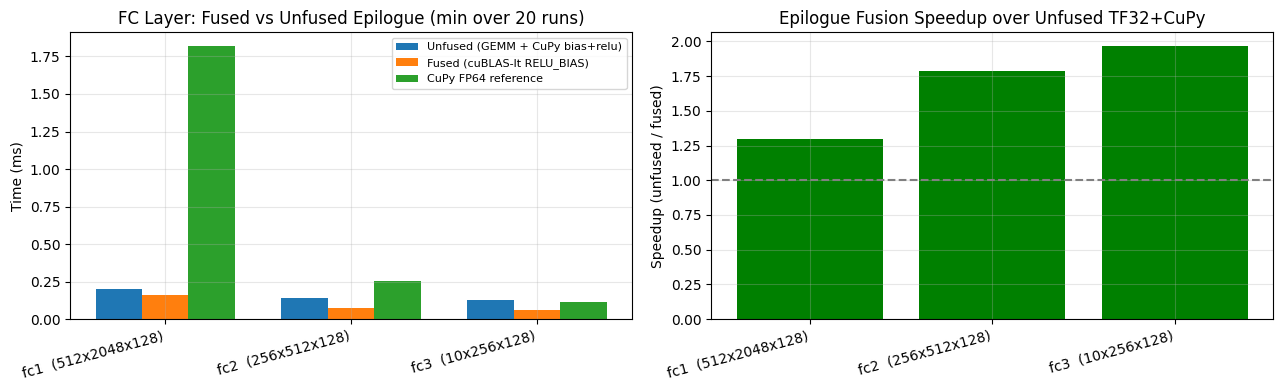

In [59]:
# ============================================================
# v5 Benchmark: cuBLAS-lt Epilogue Fusion
#
# Compares three approaches for GEMM + bias + relu at FC layer shapes:
#
#   unfused  — batched_matmul (pure TF32 GEMM) + separate CuPy bias+relu
#              Two global-memory passes: GEMM writes C, then bias/relu reads+writes C
#
#   fused    — batched_matmul_bias_relu (cuBLAS-lt CUBLASLT_EPILOGUE_RELU_BIAS)
#              One global-memory pass: bias+relu applied in registers
#              before the GEMM output is written to global memory
#
#   cupy_ref — cp.maximum(a @ b + bias[:, None], 0.0)  (pure CuPy, FP64 baseline)
#
# FC layer shapes tested:
#   fc1  M=512  K=2048 N=128  (largest, most bandwidth-sensitive)
#   fc2  M=256  K=512  N=128
#   fc3  M=10   K=256  N=128  (smallest)
# ============================================================

import numpy as np
import cupy as cp
import ctypes
import time
import matplotlib.pyplot as plt
from tensor_matrix_ops import TensorMatrixOps

ops = TensorMatrixOps()

REPEAT = 20   # timing repeats per measurement
WARMUP = 5    # discard first N runs

def _sync_time(fn, *args, repeat=REPEAT, warmup=WARMUP):
    """Time fn(*args) with GPU sync; return (result, min_ms, median_ms)."""
    times = []
    result = None
    for i in range(repeat + warmup):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        result = fn(*args)
        cp.cuda.Stream.null.synchronize()
        dt = (time.perf_counter() - t0) * 1e3  # ms
        if i >= warmup:
            times.append(dt)
    return result, min(times), float(np.median(times))

# FC layer shapes: (name, m, k, n, batch)
fc_shapes = [
    ("fc1  (512x2048x128)", 512, 2048, 128, 1),
    ("fc2  (256x512x128)",  256,  512, 128, 1),
    ("fc3  (10x256x128)",    10,  256, 128, 1),
]

print(f"{'Shape':<26} {'Unfused ms':>12} {'Fused ms':>10} {'Speedup':>9} {'CuPy ms':>10}")
print("-" * 72)

epilogue_results = []

for label, m, k, n, batch in fc_shapes:
    rng = cp.random.default_rng(42)
    A    = rng.standard_normal((batch, m, k), dtype=cp.float64)
    B    = rng.standard_normal((batch, k, n), dtype=cp.float64)
    bias = rng.standard_normal(m, dtype=cp.float64)

    # Unfused: pure GEMM then separate CuPy bias+relu
    def unfused(A, B, bias):
        C = ops.batched_matmul(A, B)
        C = C + bias[:, None]   # broadcast bias over n cols
        return cp.maximum(C, 0.0)

    # Fused: single cuBLAS-lt call (bias+relu in GEMM output registers)
    def fused(A, B, bias):
        return ops.batched_matmul_bias_relu(A, B, bias)

    # CuPy reference (FP64 matmul + bias + relu)
    def cupy_ref(A, B, bias):
        C = cp.matmul(A, B)
        C = C + bias[:, None]
        return cp.maximum(C, 0.0)

    res_unfused, t_unf_min, _ = _sync_time(unfused,  A, B, bias)
    res_fused,   t_fus_min, _ = _sync_time(fused,    A, B, bias)
    res_ref,     t_ref_min, _ = _sync_time(cupy_ref, A, B, bias)

    speedup = t_unf_min / t_fus_min

    # Correctness: fused (TF32) vs CuPy (FP64) — expect ~1e-4 from TF32 rounding
    max_err_vs_ref = float(cp.max(cp.abs(res_fused[0] - res_ref[0])))
    max_err_vs_unf = float(cp.max(cp.abs(res_fused[0] - res_unfused[0])))

    print(f"{label:<26} {t_unf_min:>10.3f}ms {t_fus_min:>8.3f}ms "
          f"{speedup:>8.2f}x {t_ref_min:>8.3f}ms")

    epilogue_results.append(dict(
        label=label, m=m, k=k, n=n, batch=batch,
        t_unfused=t_unf_min, t_fused=t_fus_min, t_cupy=t_ref_min,
        speedup=speedup, max_err_vs_ref=max_err_vs_ref, max_err_vs_unf=max_err_vs_unf,
    ))

    del A, B, bias, res_unfused, res_fused, res_ref
    cp.get_default_memory_pool().free_all_blocks()

print()
# max_err columns explained:
#   vs_ref  : fused (TF32 GEMM) vs CuPy (FP64 GEMM) — large because TF32 has
#             10-bit mantissa; for K=2048 this can be ~1e-2.  Not caused by fusion.
#   vs_unf  : fused vs unfused — both use TF32 for the GEMM; difference is
#             that unfused applies bias+relu in FP64 while fused does it in TF32.
#             Should be <1e-4 for all shapes.
print(f"{'':26} {'vs CuPy FP64':>12} {'vs unfused':>12}")
for r in epilogue_results:
    print(f"{r['label']:<26} {r['max_err_vs_ref']:>12.2e} {r['max_err_vs_unf']:>12.2e}")
print()
print("Note: vs_ref error is from TF32 rounding (same as batched_matmul), not from fusion.")
print("      vs_unf measures the accuracy cost of applying bias+relu in TF32 vs FP64.")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

labels  = [r["label"] for r in epilogue_results]
t_unf   = [r["t_unfused"] for r in epilogue_results]
t_fus   = [r["t_fused"]   for r in epilogue_results]
t_ref   = [r["t_cupy"]    for r in epilogue_results]
speedup = [r["speedup"]   for r in epilogue_results]

x = np.arange(len(labels))
w = 0.25
ax1.bar(x - w, t_unf, w, label="Unfused (GEMM + CuPy bias+relu)")
ax1.bar(x,     t_fus, w, label="Fused (cuBLAS-lt RELU_BIAS)")
ax1.bar(x + w, t_ref, w, label="CuPy FP64 reference")
ax1.set_ylabel("Time (ms)")
ax1.set_title("FC Layer: Fused vs Unfused Epilogue (min over 20 runs)")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha="right")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.bar(x, speedup, color="green")
ax2.axhline(1.0, color="gray", linestyle="--")
ax2.set_ylabel("Speedup (unfused / fused)")
ax2.set_title("Epilogue Fusion Speedup over Unfused TF32+CuPy")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha="right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [60]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


14484

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

Shape                        Unfused ms   Fused ms   Speedup    CuPy ms
------------------------------------------------------------------------
fc1  (512x2048x128)             0.142ms    0.098ms     1.45x    1.820ms
fc2  (256x512x128)              0.119ms    0.057ms     2.08x    0.258ms
fc3  (10x256x128)               0.113ms    0.051ms     2.21x    0.117ms

                           vs CuPy FP64   vs unfused
fc1  (512x2048x128)            5.55e-02     7.73e-03
fc2  (256x512x128)             2.70e-02     3.72e-03
fc3  (10x256x128)              1.07e-05     1.76e-02

Note: vs_ref error is from TF32 rounding (same as batched_matmul), not from fusion.
      vs_unf measures the accuracy cost of applying bias+relu in TF32 vs FP64.


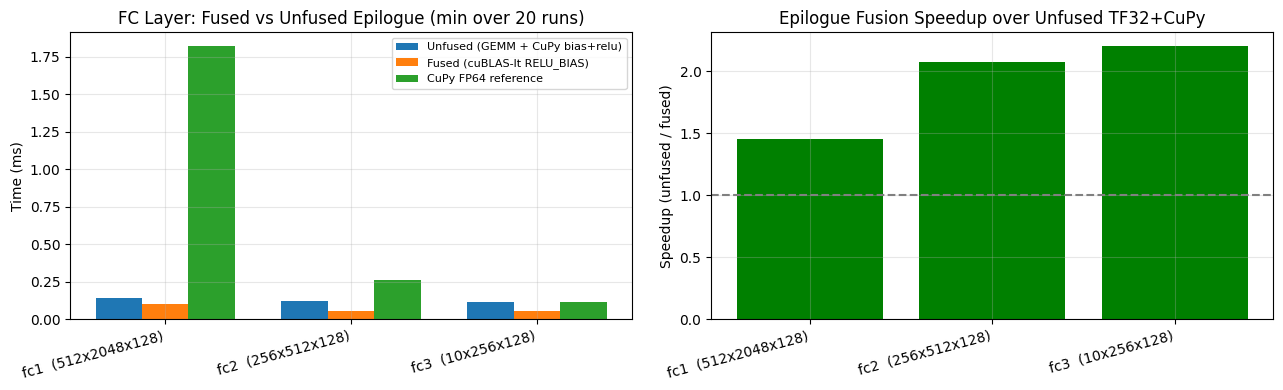

In [61]:
# ============================================================
# v5 Benchmark: cuBLAS-lt Epilogue Fusion
#
# Compares three approaches for GEMM + bias + relu at FC layer shapes:
#
#   unfused  — batched_matmul (pure TF32 GEMM) + separate CuPy bias+relu
#              Two global-memory passes: GEMM writes C, then bias/relu reads+writes C
#
#   fused    — batched_matmul_bias_relu (cuBLAS-lt CUBLASLT_EPILOGUE_RELU_BIAS)
#              One global-memory pass: bias+relu applied in registers
#              before the GEMM output is written to global memory
#
#   cupy_ref — cp.maximum(a @ b + bias[:, None], 0.0)  (pure CuPy, FP64 baseline)
#
# FC layer shapes tested:
#   fc1  M=512  K=2048 N=128  (largest, most bandwidth-sensitive)
#   fc2  M=256  K=512  N=128
#   fc3  M=10   K=256  N=128  (smallest)
# ============================================================

import numpy as np
import cupy as cp
import ctypes
import time
import matplotlib.pyplot as plt
from rust_matrix_ops import RustMatrixOps

ops = RustMatrixOps()

REPEAT = 20   # timing repeats per measurement
WARMUP = 5    # discard first N runs

def _sync_time(fn, *args, repeat=REPEAT, warmup=WARMUP):
    """Time fn(*args) with GPU sync; return (result, min_ms, median_ms)."""
    times = []
    result = None
    for i in range(repeat + warmup):
        cp.cuda.runtime.deviceSynchronize()
        t0 = time.perf_counter()
        result = fn(*args)
        cp.cuda.Stream.null.synchronize()
        dt = (time.perf_counter() - t0) * 1e3  # ms
        if i >= warmup:
            times.append(dt)
    return result, min(times), float(np.median(times))

# FC layer shapes: (name, m, k, n, batch)
fc_shapes = [
    ("fc1  (512x2048x128)", 512, 2048, 128, 1),
    ("fc2  (256x512x128)",  256,  512, 128, 1),
    ("fc3  (10x256x128)",    10,  256, 128, 1),
]

print(f"{'Shape':<26} {'Unfused ms':>12} {'Fused ms':>10} {'Speedup':>9} {'CuPy ms':>10}")
print("-" * 72)

epilogue_results = []

for label, m, k, n, batch in fc_shapes:
    rng = cp.random.default_rng(42)
    A    = rng.standard_normal((batch, m, k), dtype=cp.float64)
    B    = rng.standard_normal((batch, k, n), dtype=cp.float64)
    bias = rng.standard_normal(m, dtype=cp.float64)

    # Unfused: pure GEMM then separate CuPy bias+relu
    def unfused(A, B, bias):
        C = ops.batched_matmul(A, B)
        C = C + bias[:, None]   # broadcast bias over n cols
        return cp.maximum(C, 0.0)

    # Fused: single cuBLAS-lt call (bias+relu in GEMM output registers)
    def fused(A, B, bias):
        return ops.batched_matmul_bias_relu(A, B, bias)

    # CuPy reference (FP64 matmul + bias + relu)
    def cupy_ref(A, B, bias):
        C = cp.matmul(A, B)
        C = C + bias[:, None]
        return cp.maximum(C, 0.0)

    res_unfused, t_unf_min, _ = _sync_time(unfused,  A, B, bias)
    res_fused,   t_fus_min, _ = _sync_time(fused,    A, B, bias)
    res_ref,     t_ref_min, _ = _sync_time(cupy_ref, A, B, bias)

    speedup = t_unf_min / t_fus_min

    # Correctness: fused (TF32) vs CuPy (FP64) — expect ~1e-4 from TF32 rounding
    max_err_vs_ref = float(cp.max(cp.abs(res_fused[0] - res_ref[0])))
    max_err_vs_unf = float(cp.max(cp.abs(res_fused[0] - res_unfused[0])))

    print(f"{label:<26} {t_unf_min:>10.3f}ms {t_fus_min:>8.3f}ms "
          f"{speedup:>8.2f}x {t_ref_min:>8.3f}ms")

    epilogue_results.append(dict(
        label=label, m=m, k=k, n=n, batch=batch,
        t_unfused=t_unf_min, t_fused=t_fus_min, t_cupy=t_ref_min,
        speedup=speedup, max_err_vs_ref=max_err_vs_ref, max_err_vs_unf=max_err_vs_unf,
    ))

    del A, B, bias, res_unfused, res_fused, res_ref
    cp.get_default_memory_pool().free_all_blocks()

print()
# max_err columns explained:
#   vs_ref  : fused (TF32 GEMM) vs CuPy (FP64 GEMM) — large because TF32 has
#             10-bit mantissa; for K=2048 this can be ~1e-2.  Not caused by fusion.
#   vs_unf  : fused vs unfused — both use TF32 for the GEMM; difference is
#             that unfused applies bias+relu in FP64 while fused does it in TF32.
#             Should be <1e-4 for all shapes.
print(f"{'':26} {'vs CuPy FP64':>12} {'vs unfused':>12}")
for r in epilogue_results:
    print(f"{r['label']:<26} {r['max_err_vs_ref']:>12.2e} {r['max_err_vs_unf']:>12.2e}")
print()
print("Note: vs_ref error is from TF32 rounding (same as batched_matmul), not from fusion.")
print("      vs_unf measures the accuracy cost of applying bias+relu in TF32 vs FP64.")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

labels  = [r["label"] for r in epilogue_results]
t_unf   = [r["t_unfused"] for r in epilogue_results]
t_fus   = [r["t_fused"]   for r in epilogue_results]
t_ref   = [r["t_cupy"]    for r in epilogue_results]
speedup = [r["speedup"]   for r in epilogue_results]

x = np.arange(len(labels))
w = 0.25
ax1.bar(x - w, t_unf, w, label="Unfused (GEMM + CuPy bias+relu)")
ax1.bar(x,     t_fus, w, label="Fused (cuBLAS-lt RELU_BIAS)")
ax1.bar(x + w, t_ref, w, label="CuPy FP64 reference")
ax1.set_ylabel("Time (ms)")
ax1.set_title("FC Layer: Fused vs Unfused Epilogue (min over 20 runs)")
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha="right")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.bar(x, speedup, color="green")
ax2.axhline(1.0, color="gray", linestyle="--")
ax2.set_ylabel("Speedup (unfused / fused)")
ax2.set_title("Epilogue Fusion Speedup over Unfused TF32+CuPy")
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha="right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [62]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


7120

Starting comparison...

Testing shape: (2, 2, 2, 16, 16)
Operations: 65,536
Initializing CUDA...
CUDA initialization complete
Function signatures configured
Running tensor core tests...
Tensor Run 1: 0.72ms (0.09 GFLOPS)
Tensor Run 2: 0.17ms (0.39 GFLOPS)
Tensor Run 3: 0.14ms (0.48 GFLOPS)
Tensor Run 4: 0.14ms (0.47 GFLOPS)
Tensor Run 5: 0.14ms (0.48 GFLOPS)
Running CuPy tests...

Matrix multiplication dimensions:
a_2d shape: (8, 16, 16)
b_2d shape: (8, 16, 16)
CuPy Run 1: 1.23ms (0.05 GFLOPS)
CuPy Run 2: 0.79ms (0.08 GFLOPS)
CuPy Run 3: 0.76ms (0.09 GFLOPS)
CuPy Run 4: 0.82ms (0.08 GFLOPS)
CuPy Run 5: 0.77ms (0.09 GFLOPS)
c_cupy shape: (2, 2, 2, 16, 16)
Computing differences...

Testing shape: (4, 4, 4, 32, 32)
Operations: 4,194,304
Initializing CUDA...
CUDA initialization complete
Function signatures configured
Running tensor core tests...
Tensor Run 1: 0.45ms (9.24 GFLOPS)
Tensor Run 2: 0.17ms (23.98 GFLOPS)
Tensor Run 3: 0.16ms (25.99 GFLOPS)
Tensor Run 4: 0.16ms (26.08 GFLOPS)
Ten

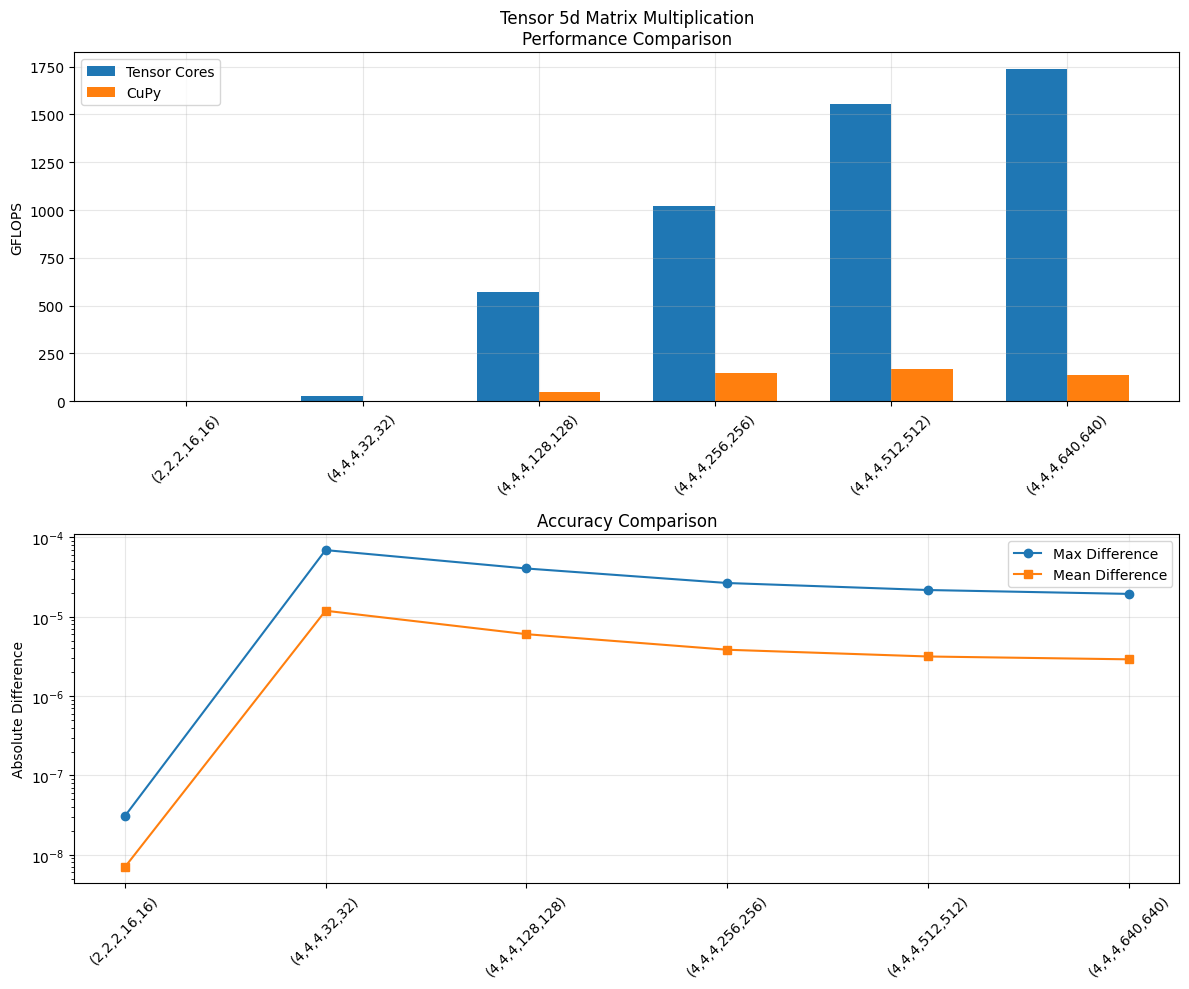


Detailed Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS     CuPy GFLOPS     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(2,2,2,16,16)                        0.48            0.09     3.04e-08     6.93e-09
(4,4,4,32,32)                       26.08            0.72     6.91e-05     1.19e-05
(4,4,4,128,128)                    569.64           45.80     4.05e-05     6.02e-06
(4,4,4,256,256)                   1020.92          146.25     2.66e-05     3.83e-06
(4,4,4,512,512)                   1555.84          169.18     2.17e-05     3.15e-06
(4,4,4,640,640)                   1738.92          138.89     1.94e-05     2.90e-06

Sample Output Comparison (first 5 values):
--------------------------------------------------------------------------------

Shape: (2, 2, 2, 16, 16)
Tensor: [0.19986062 0.24777256 0.2200928  0.18070689 0.20032153]
CuPy:   [0.1

In [63]:
import numpy as np
import cupy as cp
import time
from tensor_matrix_ops import TensorMatrixOps
import matplotlib.pyplot as plt

def tensor_vs_cupy_comparison(shapes=None, num_runs=5, seed=42):  # Add a seed argument
    """Compare tensor core vs cupy implementation for performance and accuracy."""

    # Set the random seeds for reproducibility
    np.random.seed(seed)  # Set NumPy seed
    cp.random.seed(seed)  # Set CuPy seed

    # ... (rest of the function remains the same) ...
    # Default test shapes if none provided
    if shapes is None:
        # (batch, channels, depth, height, width)
        shapes = [
            (2, 2, 2, 16, 16),    
            (4, 4, 4, 32, 32),    
            (4, 4, 4, 128, 128),  
            (4, 4, 4, 256, 256), 
            (4, 4, 4, 512, 512),
            (4, 4, 4, 640, 640)
        ]

    results = []

    for shape in shapes:
        print(f"\nTesting shape: {shape}")
        batch_size, channels, depth, height, width = shape
        new_width = width  # For these tests.  Could be different.

        # Calculate theoretical operations
        flops = 2 * batch_size * channels * depth * height * width * new_width
        print(f"Operations: {flops:,}")

        try:
            # Initialize implementations
            tensor_ops = TensorMatrixOps()

            # Create test data (Fortran order)
            a = cp.random.random(shape, dtype=cp.float64)
            a = cp.asfortranarray(a)
            b = cp.random.random((batch_size, channels, depth, width, new_width), dtype=cp.float64)
            b = cp.asfortranarray(b)


            # Scale inputs to prevent overflow
            scale = cp.sqrt(width)
            a /= (scale * 1.1)
            b /= (scale * 1.1)

            # Time tensor core implementation
            tensor_times = []
            print("Running tensor core tests...")
            for i in range(num_runs):
                start = time.perf_counter()
                c_tensor = tensor_ops.tensor_5d_matmul(a, b)  # Pass a and b directly
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                tensor_times.append(elapsed)
                tensor_gflops = flops / (elapsed * 1e9)
                print(f"Tensor Run {i+1}: {elapsed*1000:.2f}ms ({tensor_gflops:.2f} GFLOPS)")


            # Time cupy implementation
            print("Running CuPy tests...")
            cupy_times = []
            # Reshape for cupy with correct dimensions
            a_2d = a.reshape(batch_size * channels * depth, height, width)
            b_2d = b.reshape(batch_size * channels * depth, width, new_width)

            print(f"\nMatrix multiplication dimensions:")
            print(f"a_2d shape: {a_2d.shape}")
            print(f"b_2d shape: {b_2d.shape}")

            for i in range(num_runs):
                start = time.perf_counter()
                c_cupy_reshaped = cp.zeros((batch_size * channels * depth, height, new_width), order='F', dtype=cp.float64)

                for j in range(batch_size * channels * depth):
                  c_cupy_reshaped[j,:,:] = cp.matmul(a_2d[j,:,:], b_2d[j,:,:])

                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                cupy_times.append(elapsed)
                cupy_gflops = flops / (elapsed * 1e9)
                print(f"CuPy Run {i+1}: {elapsed*1000:.2f}ms ({cupy_gflops:.2f} GFLOPS)")
            c_cupy = c_cupy_reshaped.reshape(batch_size, channels, depth, height, new_width)
            print(f"c_cupy shape: {c_cupy.shape}")


            # Compare results
            print("Computing differences...")
            max_diff = cp.max(cp.abs(c_tensor - c_cupy))
            mean_diff = cp.mean(cp.abs(c_tensor - c_cupy))
            std_diff = cp.std(cp.abs(c_tensor - c_cupy))

            # Store results
            results.append({
                'shape': shape,
                'flops': flops,
                'tensor_times': tensor_times,
                'cupy_times': cupy_times,
                'tensor_gflops': flops / (min(tensor_times) * 1e9),
                'cupy_gflops': flops / (min(cupy_times) * 1e9),
                'max_diff': float(max_diff),
                'mean_diff': float(mean_diff),
                'std_diff': float(std_diff),
                'sample_tensor': cp.asnumpy(c_tensor[0,0,0,0,:5]),
                'sample_cupy': cp.asnumpy(c_cupy[0,0,0,0,:5])
            })

            # Clean up GPU memory
            del a, b, c_tensor, c_cupy, a_2d, b_2d, c_cupy_reshaped
            cp.get_default_memory_pool().free_all_blocks()

        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()

    # Plot results if we have any
    if results:
        plot_comparison(results)

        # Print detailed comparison
        print("\nDetailed Comparison:")
        print("-" * 80)
        print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'CuPy GFLOPS':>15} {'Max Diff':>12} {'Mean Diff':>12}")
        print("-" * 80)

        for r in results:
            shape_str = f"({','.join(map(str, r['shape']))})"
            print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['cupy_gflops']:15.2f} "
                  f"{r['max_diff']:12.2e} {r['mean_diff']:12.2e}")

        print("\nSample Output Comparison (first 5 values):")
        print("-" * 80)
        for r in results:
            print(f"\nShape: {r['shape']}")
            print(f"Tensor: {r['sample_tensor']}")
            print(f"CuPy:   {r['sample_cupy']}")

    return results

def plot_comparison(results):
    """Create comparison plots for performance and accuracy."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Performance comparison
    shapes = [f"({','.join(map(str, r['shape']))})" for r in results]
    tensor_gflops = [r['tensor_gflops'] for r in results]
    cupy_gflops = [r['cupy_gflops'] for r in results]

    x = np.arange(len(shapes))
    width = 0.35
    operation_name="Tensor 5d Matrix Multiplication"

    ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
    ax1.bar(x + width/2, cupy_gflops, width, label='CuPy')
    ax1.set_ylabel('GFLOPS')
    ax1.set_title(f'{operation_name}\nPerformance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(shapes, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy comparison
    max_diffs = [r['max_diff'] for r in results]
    mean_diffs = [r['mean_diff'] for r in results]

    ax2.plot(x, max_diffs, 'o-', label='Max Difference')
    ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
    ax2.set_ylabel('Absolute Difference')
    ax2.set_title('Accuracy Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels(shapes, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Starting comparison...")
    try:
        results = tensor_vs_cupy_comparison() # Use default seed, or specify one
        # results = tensor_vs_cupy_comparison(seed=123)  # Example with a different seed
    except Exception as e:
        print(f"Test failed: {e}")

# it is CuPy that is running out of memory, not the tensor cores!

In [64]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


23306

**Rust equivalent of the cell above** (same code, `RustMatrixOps`):

Starting comparison...

Testing shape: (2, 2, 2, 16, 16)
Operations: 65,536
Running tensor core tests...
Tensor Run 1: 0.31ms (0.21 GFLOPS)
Tensor Run 2: 0.15ms (0.45 GFLOPS)
Tensor Run 3: 0.15ms (0.43 GFLOPS)
Tensor Run 4: 0.13ms (0.50 GFLOPS)
Tensor Run 5: 0.13ms (0.50 GFLOPS)
Running CuPy tests...

Matrix multiplication dimensions:
a_2d shape: (8, 16, 16)
b_2d shape: (8, 16, 16)
CuPy Run 1: 0.98ms (0.07 GFLOPS)
CuPy Run 2: 0.78ms (0.08 GFLOPS)
CuPy Run 3: 0.76ms (0.09 GFLOPS)
CuPy Run 4: 0.75ms (0.09 GFLOPS)
CuPy Run 5: 0.76ms (0.09 GFLOPS)
c_cupy shape: (2, 2, 2, 16, 16)
Computing differences...

Testing shape: (4, 4, 4, 32, 32)
Operations: 4,194,304
Running tensor core tests...
Tensor Run 1: 0.24ms (17.68 GFLOPS)
Tensor Run 2: 0.11ms (39.70 GFLOPS)
Tensor Run 3: 0.10ms (43.15 GFLOPS)
Tensor Run 4: 0.10ms (43.68 GFLOPS)
Tensor Run 5: 0.10ms (43.94 GFLOPS)
Running CuPy tests...

Matrix multiplication dimensions:
a_2d shape: (64, 32, 32)
b_2d shape: (64, 32, 32)
CuPy Run 1: 5.88ms (0

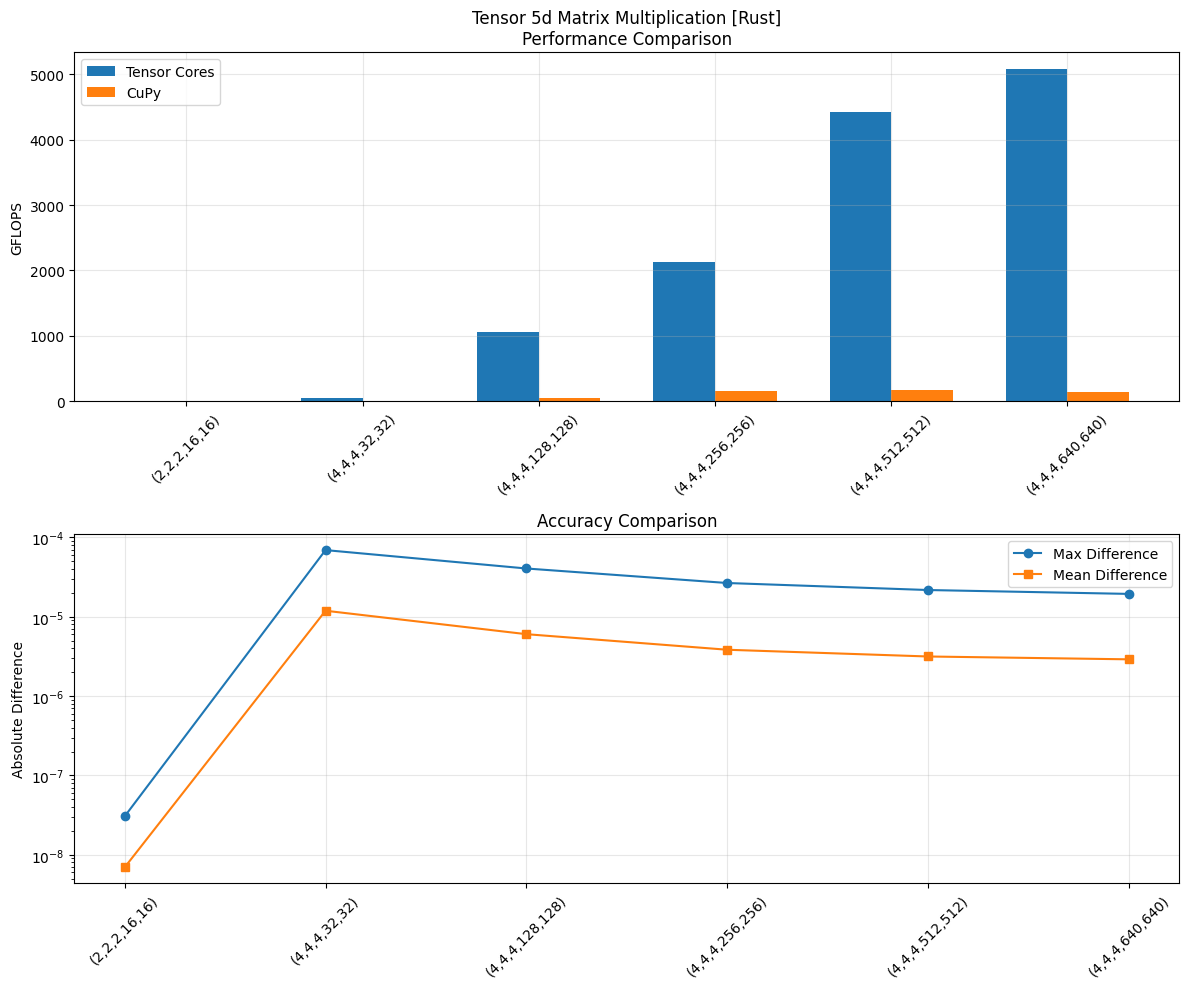


Detailed Comparison:
--------------------------------------------------------------------------------
Shape                       Tensor GFLOPS     CuPy GFLOPS     Max Diff    Mean Diff
--------------------------------------------------------------------------------
(2,2,2,16,16)                        0.50            0.09     3.04e-08     6.93e-09
(4,4,4,32,32)                       43.94            0.73     6.91e-05     1.19e-05
(4,4,4,128,128)                   1056.85           45.93     4.05e-05     6.02e-06
(4,4,4,256,256)                   2132.59          148.25     2.66e-05     3.83e-06
(4,4,4,512,512)                   4421.17          169.11     2.17e-05     3.15e-06
(4,4,4,640,640)                   5083.67          139.37     1.94e-05     2.90e-06

Sample Output Comparison (first 5 values):
--------------------------------------------------------------------------------

Shape: (2, 2, 2, 16, 16)
Tensor: [0.19986062 0.24777256 0.2200928  0.18070689 0.20032153]
CuPy:   [0.1

In [65]:
import numpy as np
import cupy as cp
import time
from rust_matrix_ops import RustMatrixOps
import matplotlib.pyplot as plt

def tensor_vs_cupy_comparison(shapes=None, num_runs=5, seed=42):  # Add a seed argument
    """Compare tensor core vs cupy implementation for performance and accuracy."""

    # Set the random seeds for reproducibility
    np.random.seed(seed)  # Set NumPy seed
    cp.random.seed(seed)  # Set CuPy seed

    # ... (rest of the function remains the same) ...
    # Default test shapes if none provided
    if shapes is None:
        # (batch, channels, depth, height, width)
        shapes = [
            (2, 2, 2, 16, 16),    
            (4, 4, 4, 32, 32),    
            (4, 4, 4, 128, 128),  
            (4, 4, 4, 256, 256), 
            (4, 4, 4, 512, 512),
            (4, 4, 4, 640, 640)
        ]

    results = []

    for shape in shapes:
        print(f"\nTesting shape: {shape}")
        batch_size, channels, depth, height, width = shape
        new_width = width  # For these tests.  Could be different.

        # Calculate theoretical operations
        flops = 2 * batch_size * channels * depth * height * width * new_width
        print(f"Operations: {flops:,}")

        try:
            # Initialize implementations
            tensor_ops = RustMatrixOps()

            # Create test data (Fortran order)
            a = cp.random.random(shape, dtype=cp.float64)
            a = cp.asfortranarray(a)
            b = cp.random.random((batch_size, channels, depth, width, new_width), dtype=cp.float64)
            b = cp.asfortranarray(b)


            # Scale inputs to prevent overflow
            scale = cp.sqrt(width)
            a /= (scale * 1.1)
            b /= (scale * 1.1)

            # Time tensor core implementation
            tensor_times = []
            print("Running tensor core tests...")
            for i in range(num_runs):
                start = time.perf_counter()
                c_tensor = tensor_ops.tensor_5d_matmul(a, b)  # Pass a and b directly
                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                tensor_times.append(elapsed)
                tensor_gflops = flops / (elapsed * 1e9)
                print(f"Tensor Run {i+1}: {elapsed*1000:.2f}ms ({tensor_gflops:.2f} GFLOPS)")


            # Time cupy implementation
            print("Running CuPy tests...")
            cupy_times = []
            # Reshape for cupy with correct dimensions
            a_2d = a.reshape(batch_size * channels * depth, height, width)
            b_2d = b.reshape(batch_size * channels * depth, width, new_width)

            print(f"\nMatrix multiplication dimensions:")
            print(f"a_2d shape: {a_2d.shape}")
            print(f"b_2d shape: {b_2d.shape}")

            for i in range(num_runs):
                start = time.perf_counter()
                c_cupy_reshaped = cp.zeros((batch_size * channels * depth, height, new_width), order='F', dtype=cp.float64)

                for j in range(batch_size * channels * depth):
                  c_cupy_reshaped[j,:,:] = cp.matmul(a_2d[j,:,:], b_2d[j,:,:])

                cp.cuda.Stream.null.synchronize()
                elapsed = time.perf_counter() - start
                cupy_times.append(elapsed)
                cupy_gflops = flops / (elapsed * 1e9)
                print(f"CuPy Run {i+1}: {elapsed*1000:.2f}ms ({cupy_gflops:.2f} GFLOPS)")
            c_cupy = c_cupy_reshaped.reshape(batch_size, channels, depth, height, new_width)
            print(f"c_cupy shape: {c_cupy.shape}")


            # Compare results
            print("Computing differences...")
            max_diff = cp.max(cp.abs(c_tensor - c_cupy))
            mean_diff = cp.mean(cp.abs(c_tensor - c_cupy))
            std_diff = cp.std(cp.abs(c_tensor - c_cupy))

            # Store results
            results.append({
                'shape': shape,
                'flops': flops,
                'tensor_times': tensor_times,
                'cupy_times': cupy_times,
                'tensor_gflops': flops / (min(tensor_times) * 1e9),
                'cupy_gflops': flops / (min(cupy_times) * 1e9),
                'max_diff': float(max_diff),
                'mean_diff': float(mean_diff),
                'std_diff': float(std_diff),
                'sample_tensor': cp.asnumpy(c_tensor[0,0,0,0,:5]),
                'sample_cupy': cp.asnumpy(c_cupy[0,0,0,0,:5])
            })

            # Clean up GPU memory
            del a, b, c_tensor, c_cupy, a_2d, b_2d, c_cupy_reshaped
            cp.get_default_memory_pool().free_all_blocks()

        except Exception as e:
            print(f"Error testing shape {shape}: {e}")
            import traceback
            traceback.print_exc()

    # Plot results if we have any
    if results:
        plot_comparison(results)

        # Print detailed comparison
        print("\nDetailed Comparison:")
        print("-" * 80)
        print(f"{'Shape':25} {'Tensor GFLOPS':>15} {'CuPy GFLOPS':>15} {'Max Diff':>12} {'Mean Diff':>12}")
        print("-" * 80)

        for r in results:
            shape_str = f"({','.join(map(str, r['shape']))})"
            print(f"{shape_str:25} {r['tensor_gflops']:15.2f} {r['cupy_gflops']:15.2f} "
                  f"{r['max_diff']:12.2e} {r['mean_diff']:12.2e}")

        print("\nSample Output Comparison (first 5 values):")
        print("-" * 80)
        for r in results:
            print(f"\nShape: {r['shape']}")
            print(f"Tensor: {r['sample_tensor']}")
            print(f"CuPy:   {r['sample_cupy']}")

    return results

def plot_comparison(results):
    """Create comparison plots for performance and accuracy."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Performance comparison
    shapes = [f"({','.join(map(str, r['shape']))})" for r in results]
    tensor_gflops = [r['tensor_gflops'] for r in results]
    cupy_gflops = [r['cupy_gflops'] for r in results]

    x = np.arange(len(shapes))
    width = 0.35
    operation_name = "Tensor 5d Matrix Multiplication [Rust]"

    ax1.bar(x - width/2, tensor_gflops, width, label='Tensor Cores')
    ax1.bar(x + width/2, cupy_gflops, width, label='CuPy')
    ax1.set_ylabel('GFLOPS')
    ax1.set_title(f'{operation_name}\nPerformance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(shapes, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy comparison
    max_diffs = [r['max_diff'] for r in results]
    mean_diffs = [r['mean_diff'] for r in results]

    ax2.plot(x, max_diffs, 'o-', label='Max Difference')
    ax2.plot(x, mean_diffs, 's-', label='Mean Difference')
    ax2.set_ylabel('Absolute Difference')
    ax2.set_title('Accuracy Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels(shapes, rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Starting comparison...")
    try:
        results = tensor_vs_cupy_comparison() # Use default seed, or specify one
        # results = tensor_vs_cupy_comparison(seed=123)  # Example with a different seed
    except Exception as e:
        print(f"Test failed: {e}")

# it is CuPy that is running out of memory, not the tensor cores!

In [66]:
# Free GPU memory between engines. Both engines keep a process-global workspace pool
# (Fortran wp_*, Rust pool) that outlives the wrapper objects the cells create locally,
# so release them through fresh handles, then drop CuPy's cached blocks.
# (A 4 GB GPU can't hold CuPy's cache + both pools at the largest shapes.)
import gc, cupy as cp
from tensor_matrix_ops import TensorMatrixOps as _F
from rust_matrix_ops import RustMatrixOps as _R
for _mk in (_F, _R):
    try: _mk().workspace_cleanup()
    except Exception as _e: print(f"{_mk.__name__}.workspace_cleanup: {_e}")
cp.cuda.runtime.deviceSynchronize(); cp.get_default_memory_pool().free_all_blocks(); cp.get_default_pinned_memory_pool().free_all_blocks(); gc.collect()


Initializing CUDA...
CUDA initialization complete
Function signatures configured


23016

## Summary: Fortran vs Rust, every operation

In [67]:
# Side-by-side summary: Fortran vs Rust for every run_benchmark-style result list above.
import pandas as pd
pairs = [(k, k + "_rust") for k in list(globals()) if k.endswith("_results") and (k + "_rust") in globals()]
rows = []
for f, r in pairs:
    fr, rr = globals()[f], globals()[r]
    if not isinstance(fr, list) or not isinstance(rr, list): continue
    for a, b in zip(fr, rr):
        if not (isinstance(a, dict) and isinstance(b, dict) and "tensor_gflops" in a and "tensor_gflops" in b): continue
        rows.append(dict(operation=f.replace("_results", ""), shape=str(a.get("shape")),
                         fortran_gflops=a["tensor_gflops"], rust_gflops=b["tensor_gflops"],
                         rust_over_fortran=b["tensor_gflops"] / a["tensor_gflops"],
                         fortran_max_diff=a.get("max_diff"), rust_max_diff=b.get("max_diff")))
summary_df = pd.DataFrame(rows)
pd.set_option("display.width", 160); pd.set_option("display.max_rows", 200)
print("Rust/Fortran > 1 means Rust faster. Same cuBLAS math on both sides; differences are wrapper overhead + noise.")
summary_df


Rust/Fortran > 1 means Rust faster. Same cuBLAS math on both sides; differences are wrapper overhead + noise.


,operation,shape,fortran_gflops,rust_gflops,rust_over_fortran,fortran_max_diff,rust_max_diff
0,matrix_power,"(16, 16)",0.159668,0.217985,1.365243,2.148024e-04,1.639729e-04
1,matrix_power,"(32, 32)",1.314506,1.695803,1.290069,4.963124e-04,4.135713e-04
2,matrix_power,"(64, 64)",11.755072,14.328333,1.218906,4.741835e-04,5.864558e-04
3,matrix_power,"(128, 128)",99.719547,123.795157,1.241433,8.916772e-04,9.918593e-04
4,matrix_power,"(256, 256)",744.314274,873.233453,1.173205,1.321383e-03,1.354173e-03
5,matrix_power,"(512, 512)",3771.670618,4608.610923,1.221902,2.048222e-03,2.404808e-03
6,matrix_power,"(768, 768)",7420.658761,9017.584415,1.215200,2.332925e-03,2.158178e-03
7,matrix_power,"(1024, 1024)",11260.525922,12496.740522,1.109783,2.849545e-03,3.037435e-03
8,matrix_power,"(2048, 2048)",18322.740988,18971.960569,1.035432,1.072382e-02,1.055847e-02
9,matrix_power,"(4048, 4048)",23794.964307,23202.351583,0.975095,3.081696e-02,3.106341e-02
